In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(ggplot2))
suppressMessages(library(data.table))
suppressMessages(library(sctransform))

In [2]:
obj <- readRDS("cellplex3_soupX.rds")

In [3]:
hvg <- read.csv("cellplex3.bigsur.hvg.csv", row.names = 1)

In [5]:
meta <- read.csv("cellplex3.adata.obs.metadata.csv", row.names=1)
colnames(meta)

[1] "orig_ident"                  "n_genes"                    
 [3] "n_genes_by_counts"           "log1p_n_genes_by_counts"    
 [5] "total_counts"                "log1p_total_counts"         
 [7] "pct_counts_in_top_50_genes"  "pct_counts_in_top_100_genes"
 [9] "pct_counts_in_top_200_genes" "pct_counts_in_top_500_genes"
[11] "total_counts_mt"             "log1p_total_counts_mt"      
[13] "pct_counts_mt"               "total_counts_ribo"          
[15] "log1p_total_counts_ribo"     "pct_counts_ribo"            
[17] "total_counts_hb"             "log1p_total_counts_hb"      
[19] "pct_counts_hb"               "leiden"                     
[21] "leiden_res_0.10"             "leiden_res_0.20"            
[23] "leiden_res_0.50"             "cell_type"

In [6]:
meta_to_add <- meta[,c(1,13,16,19,21,24)]
head(meta_to_add)

,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACCCAGTACAGTAA-1,nMFP_6,2.714191,25.140581,0,0,Fibroblasts
AAACGAAAGGCCTAAG-1,nMFP_6,2.856668,32.619167,0,4,Tcells
AAACGAATCAGAACCT-1,nMFP_6,6.487455,5.089606,0,3,LumSec
AAACGAATCGAGAAAT-1,nMFP_6,3.899594,28.809622,0,1,Basal
AAACGAATCTGCAGCG-1,nMFP_6,3.020293,25.782602,0,1,Basal
AAACGCTAGATTACCC-1,nMFP_6,3.425916,21.798334,0,1,Basal


In [7]:
obj <- AddMetaData(obj, meta_to_add)
head(obj[[]])

,orig.ident,nCount_RNA,nFeature_RNA,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACCCAGTACAGTAA-1,SeuratProject,21510.244,5124,nMFP_6,2.714191,25.140581,0,0,Fibroblasts
AAACGAAAGGCCTAAG-1,SeuratProject,5828.612,2192,nMFP_6,2.856668,32.619167,0,4,Tcells
AAACGAATCAGAACCT-1,SeuratProject,2723.076,1593,nMFP_6,6.487455,5.089606,0,3,LumSec
AAACGAATCGAGAAAT-1,SeuratProject,21135.252,4708,nMFP_6,3.899594,28.809622,0,1,Basal
AAACGAATCTGCAGCG-1,SeuratProject,6185.078,2415,nMFP_6,3.020293,25.782602,0,1,Basal
AAACGCTAGATTACCC-1,SeuratProject,8954.680,3324,nMFP_6,3.425916,21.798334,0,1,Basal


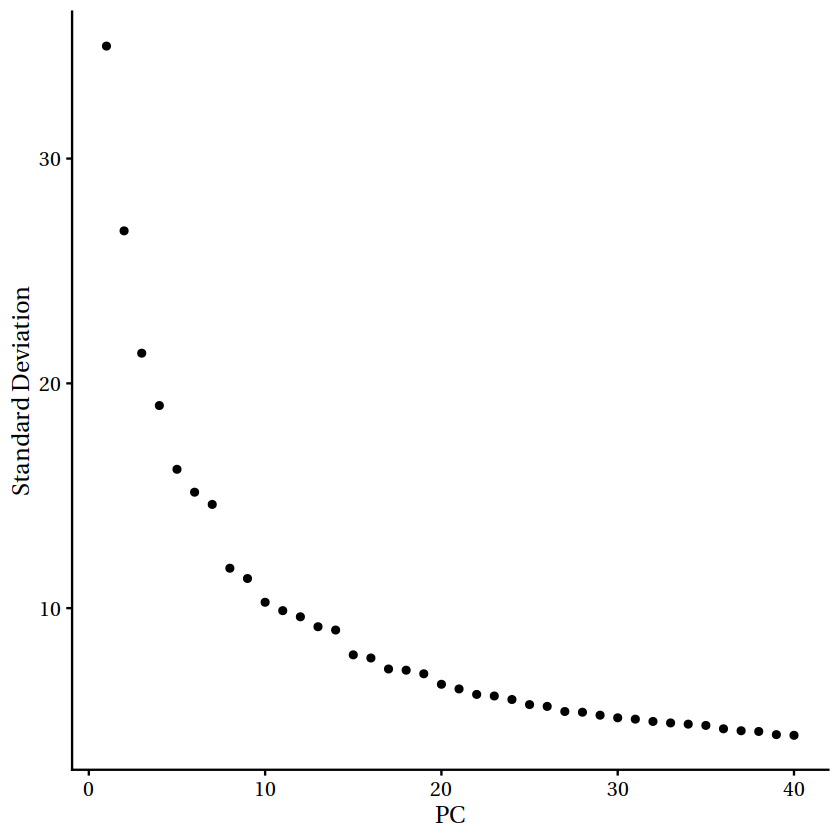

In [8]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


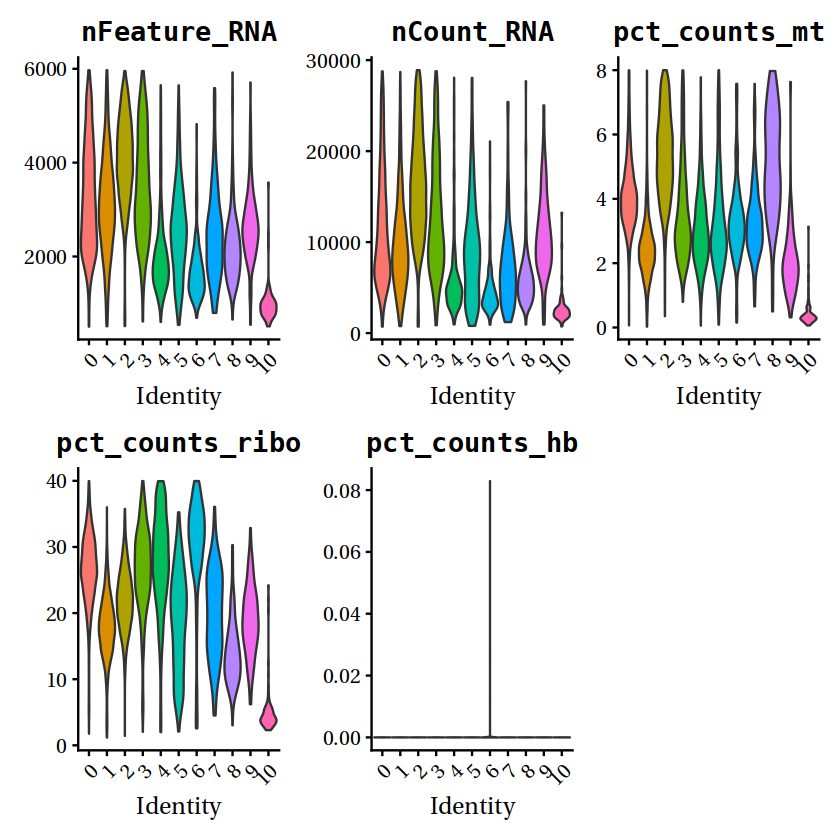

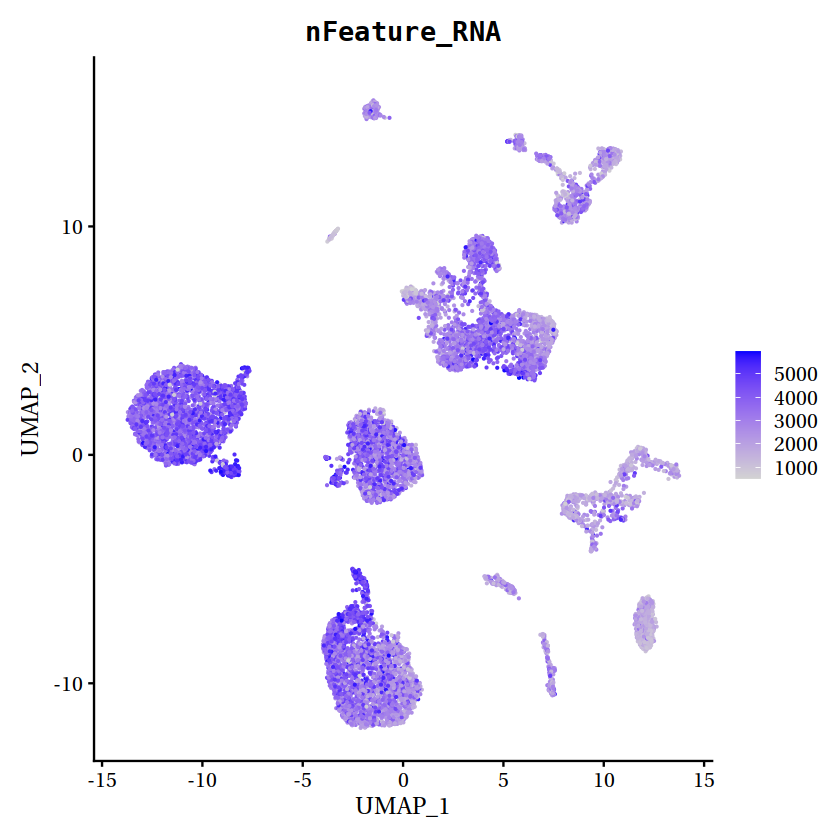

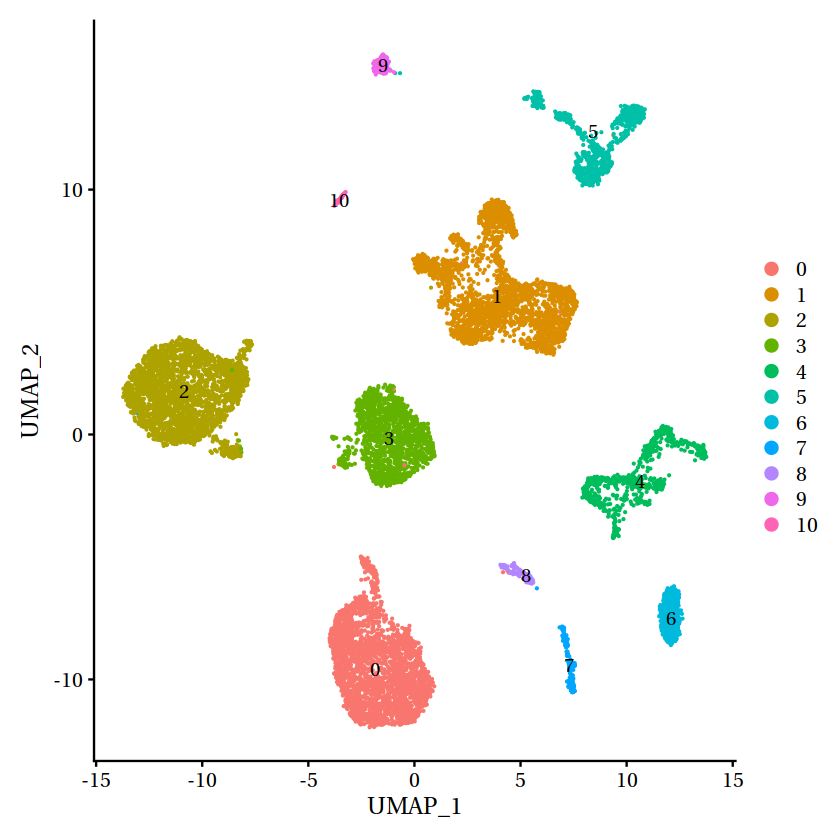

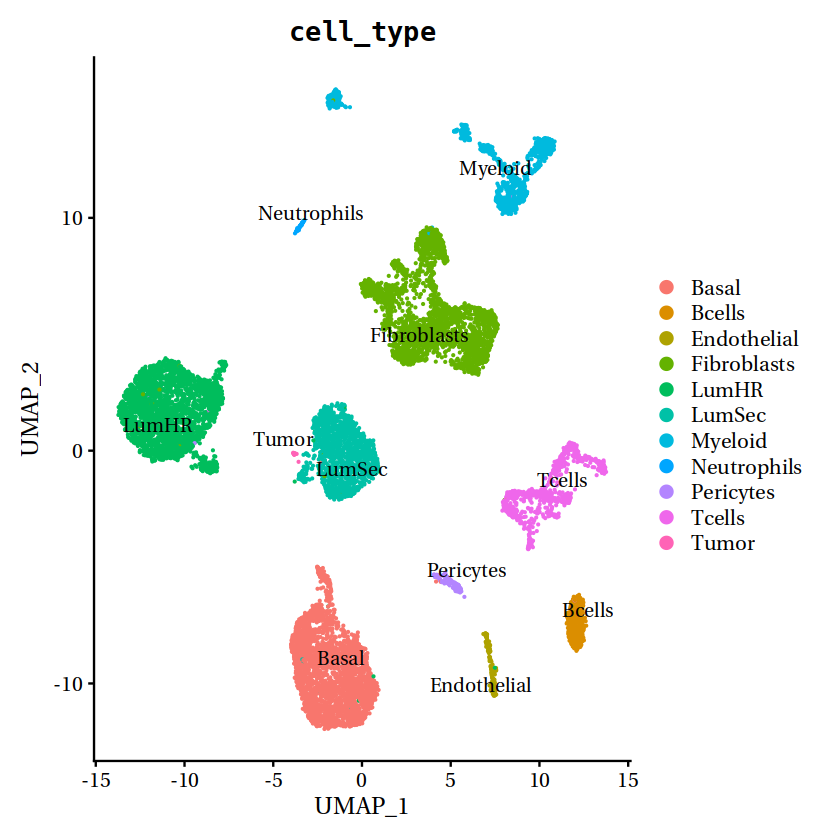

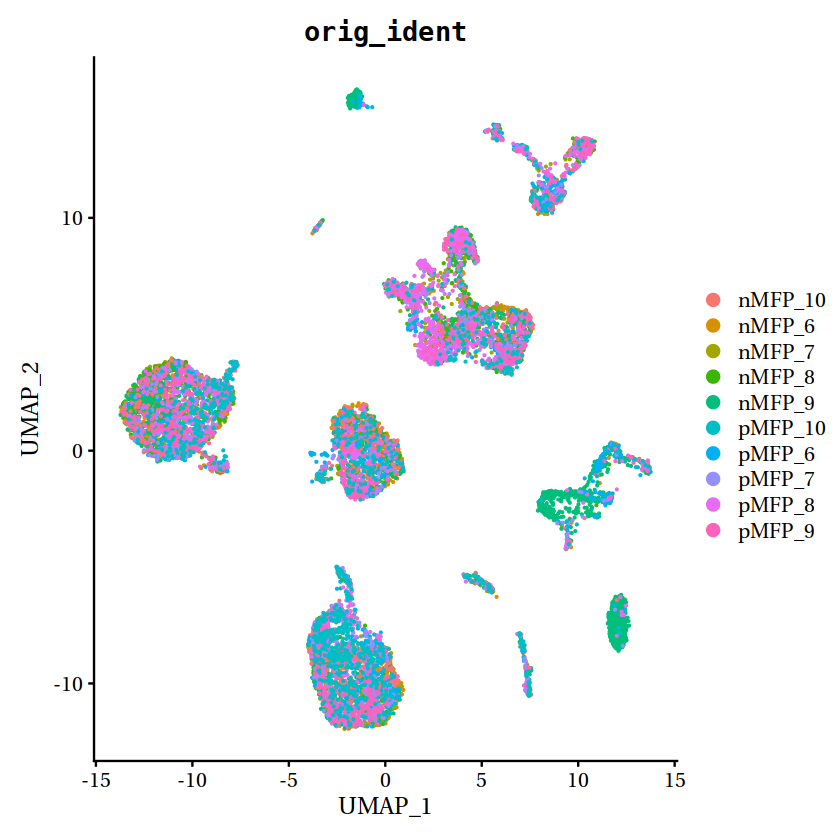

In [11]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F, repel = T)

In [27]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA < 750, WhichCells(obj, ident = 0), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 750, WhichCells(obj, ident = 3), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 2000, WhichCells(obj, ident = 2), invert = TRUE)

obj <- subset(obj, subset = nFeature_RNA > 4500, WhichCells(obj, ident = c(5,7)), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 4500, WhichCells(obj, ident = 9), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 4000, WhichCells(obj, ident = 8), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 3500, WhichCells(obj, ident = 4), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 2750, WhichCells(obj, ident = 6), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 1500, WhichCells(obj, ident = 10), invert = TRUE)

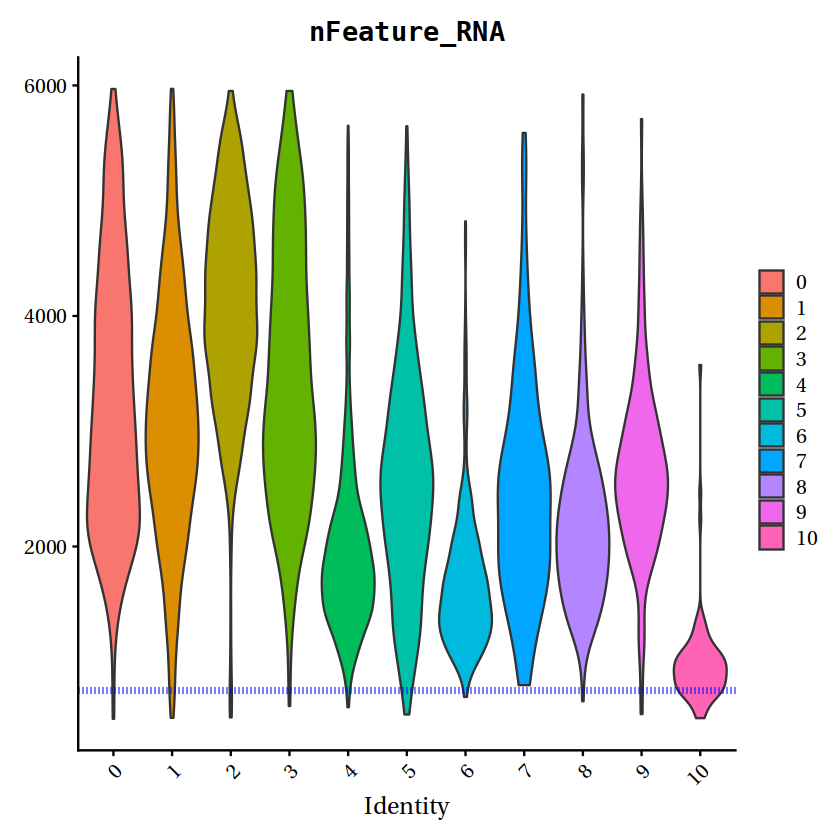

In [24]:
VlnPlot(obj, features = c("nFeature_RNA"), pt.size=0)+ geom_hline(yintercept = 750, linetype="dotted", 
                color = "blue", size=1.5)

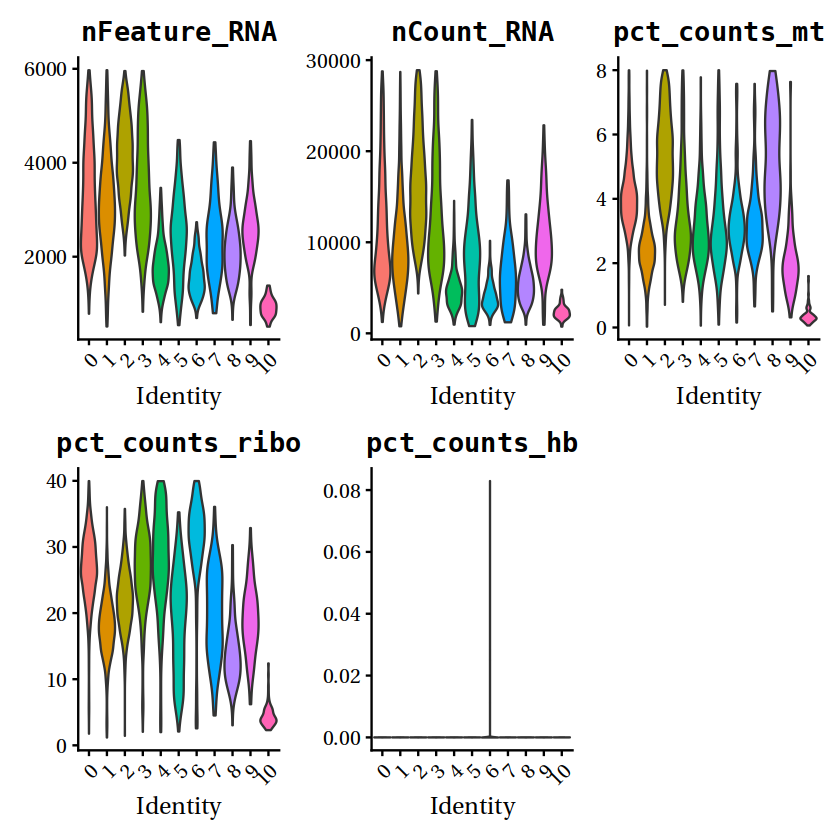

In [28]:
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)

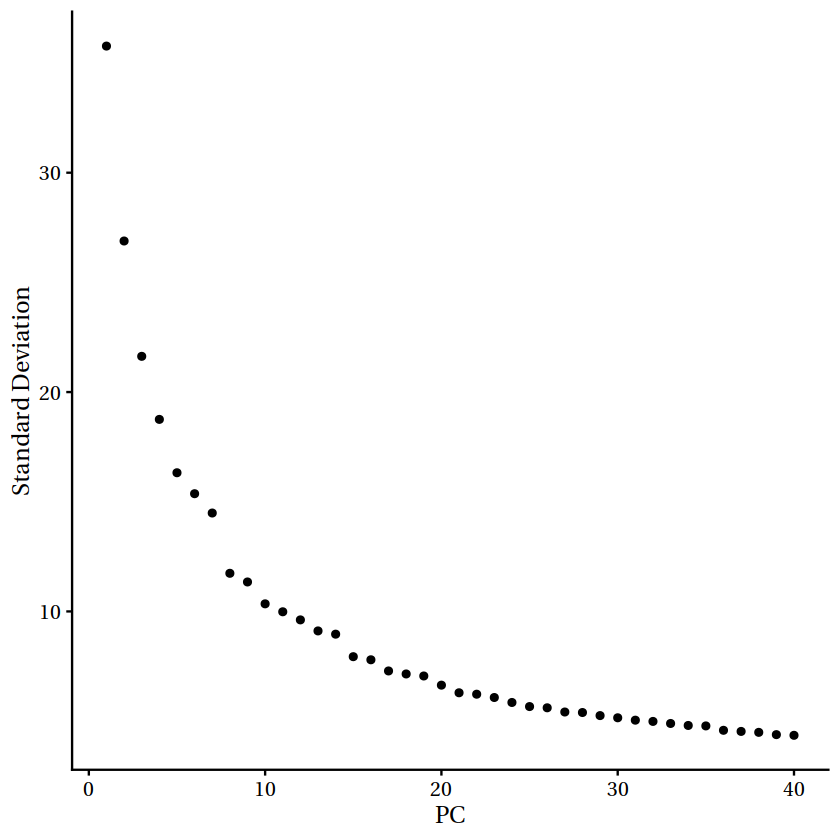

In [29]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

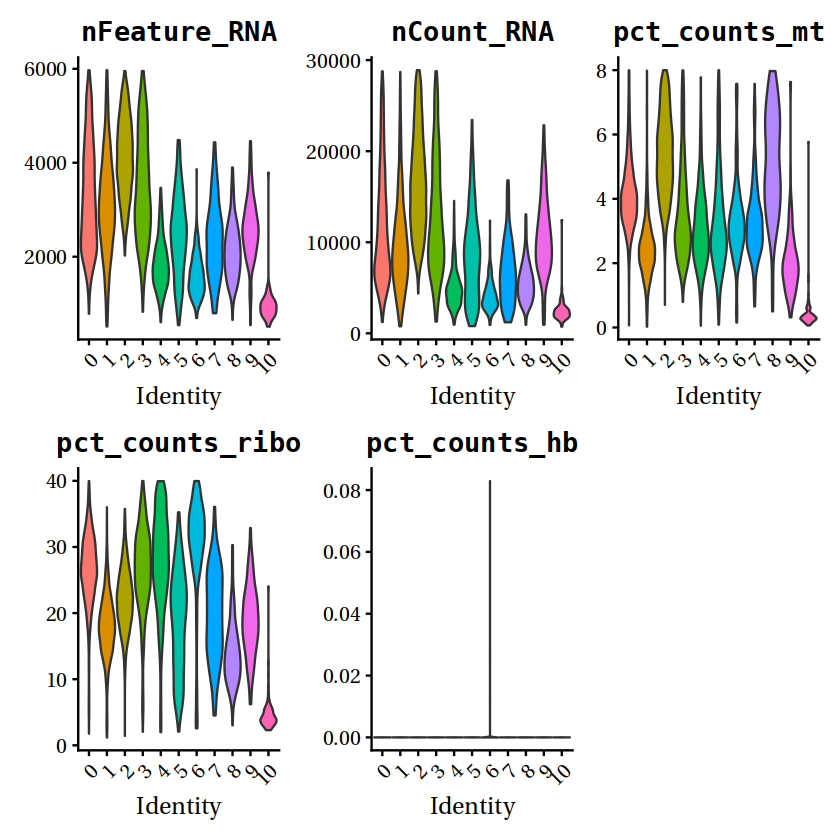

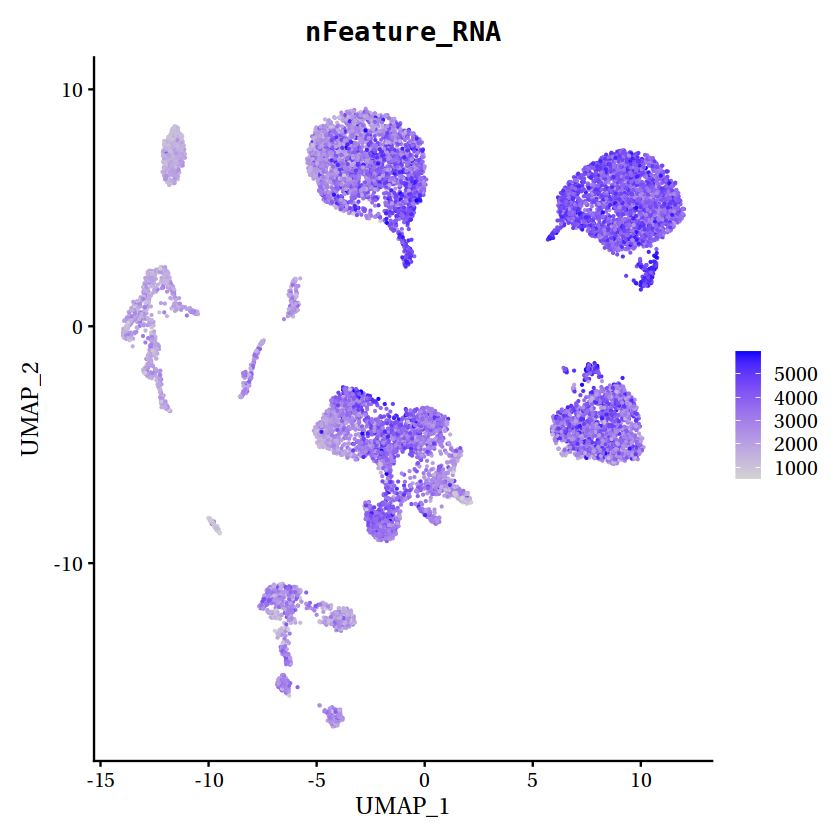

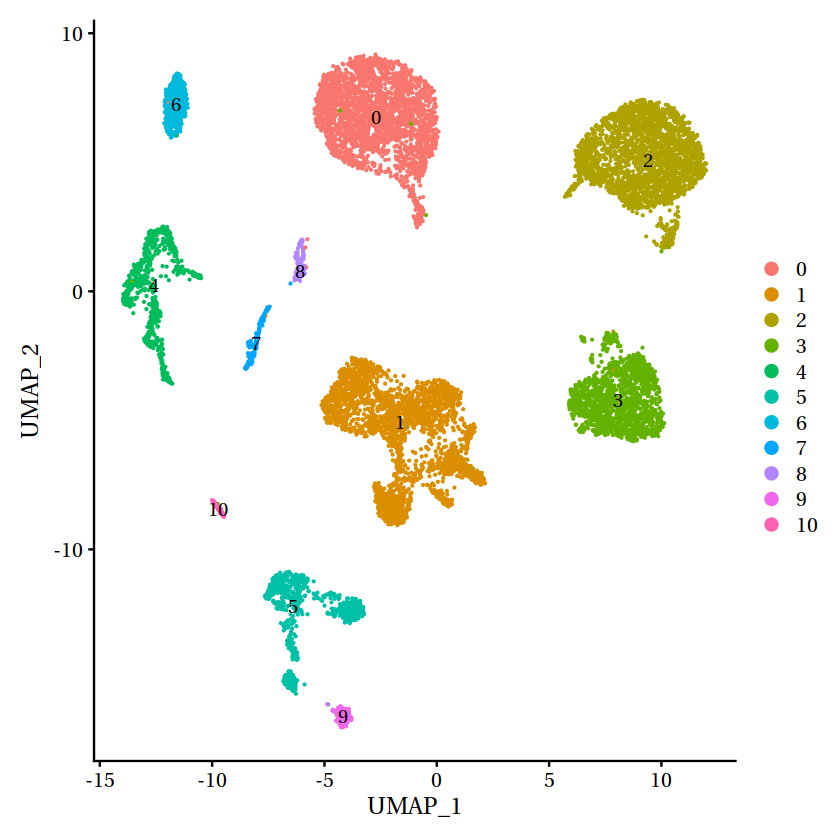

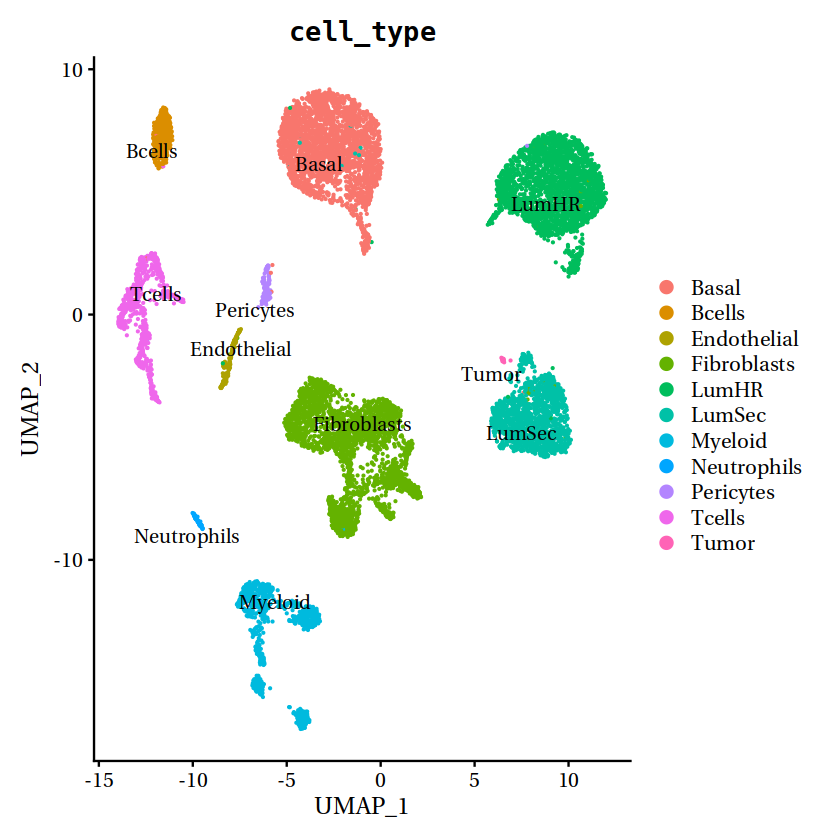

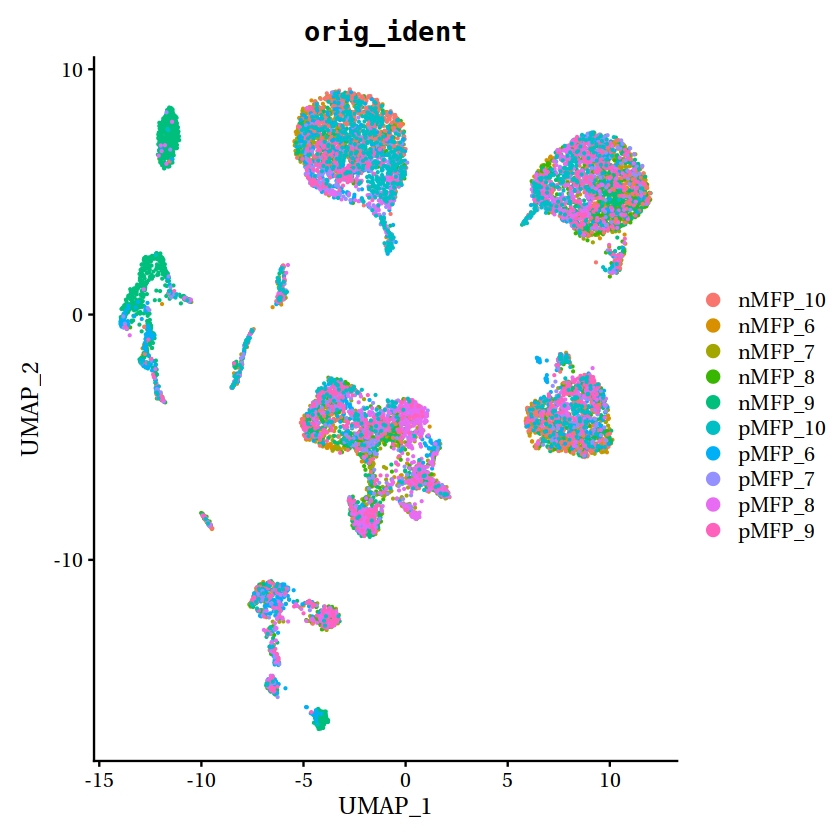

In [31]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)

In [32]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA > 2750, WhichCells(obj, ident = 6), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 1500, WhichCells(obj, ident = 10), invert = TRUE)

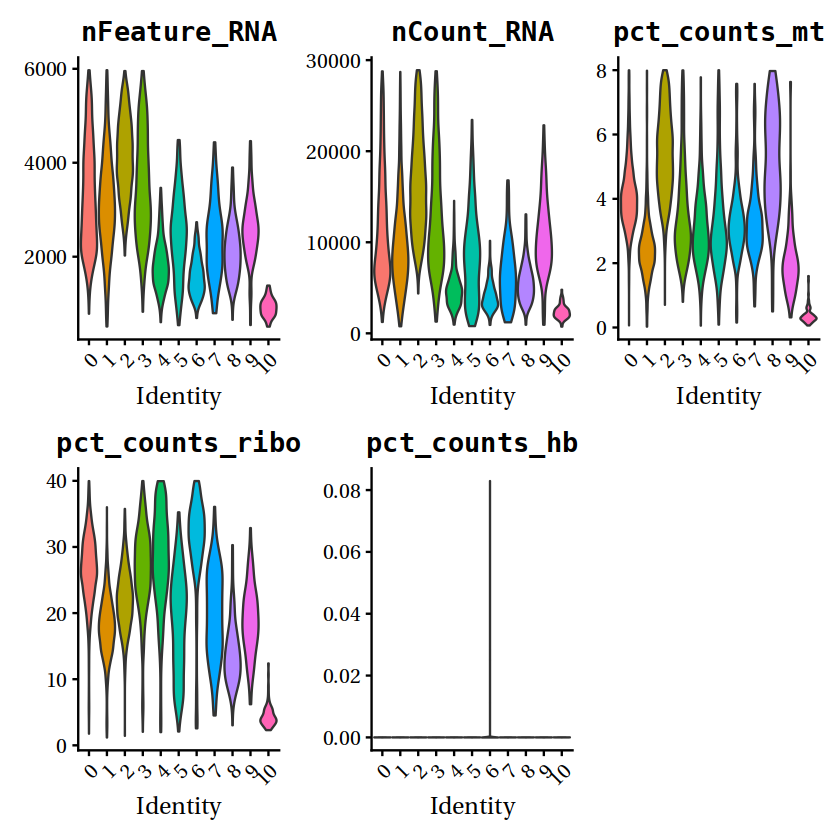

In [33]:
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)

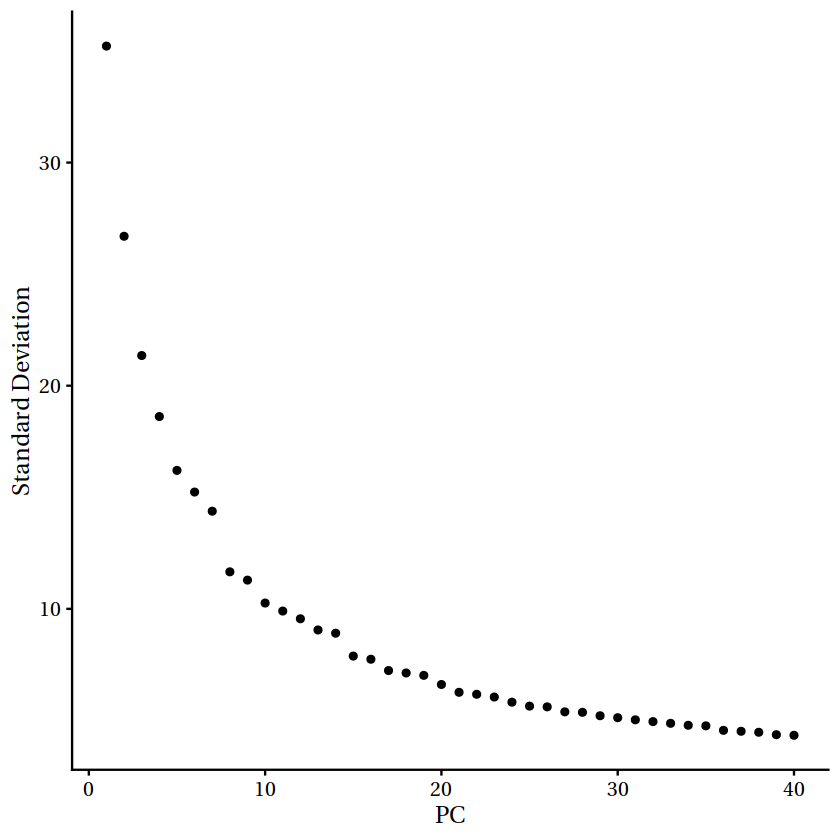

In [34]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

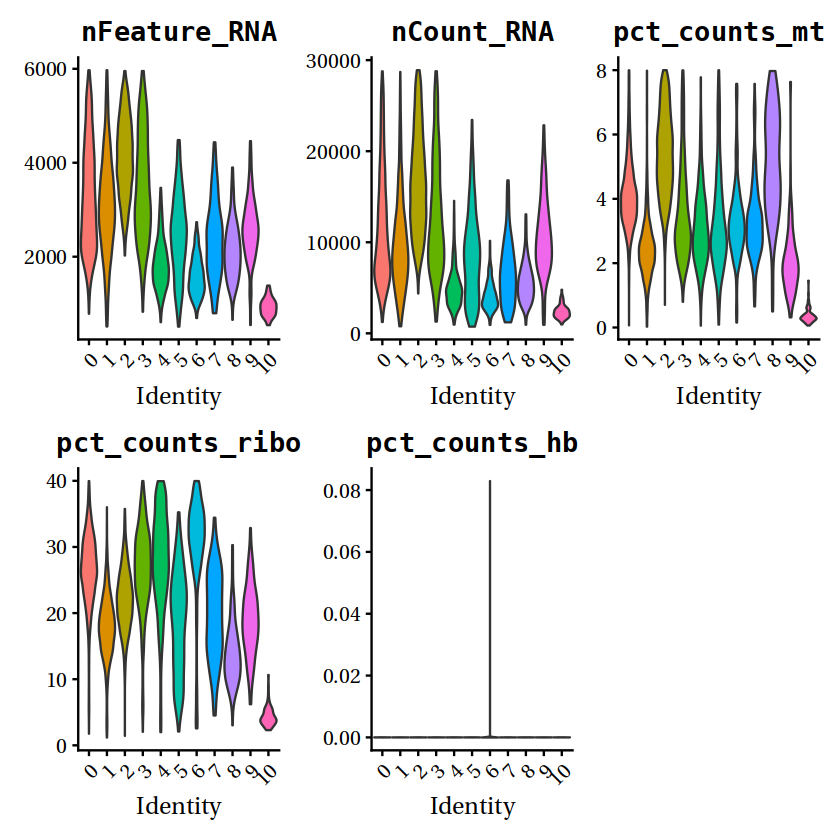

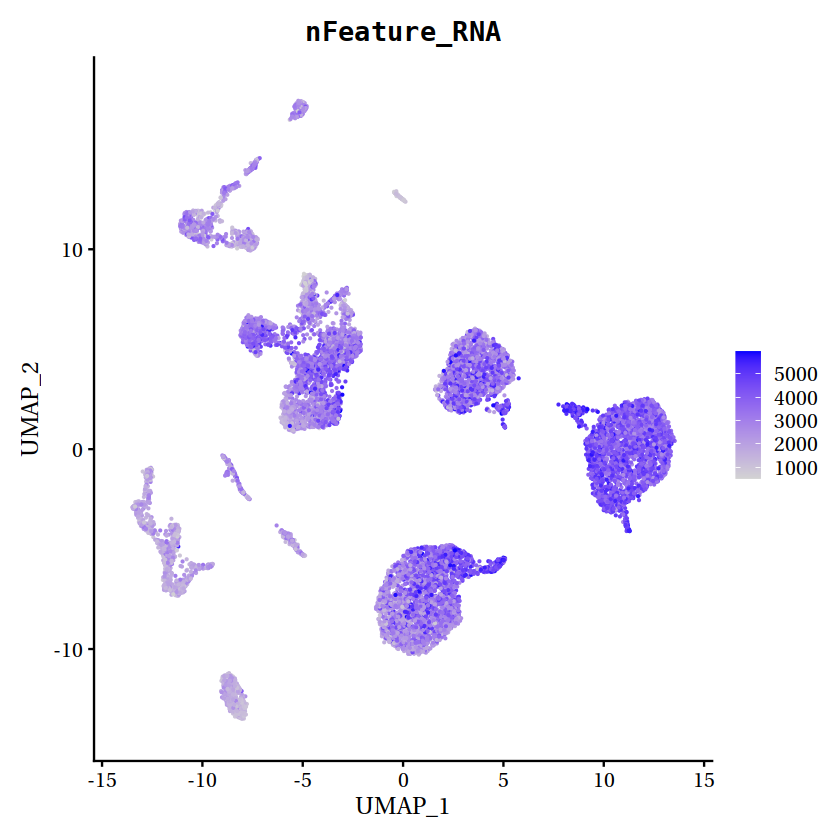

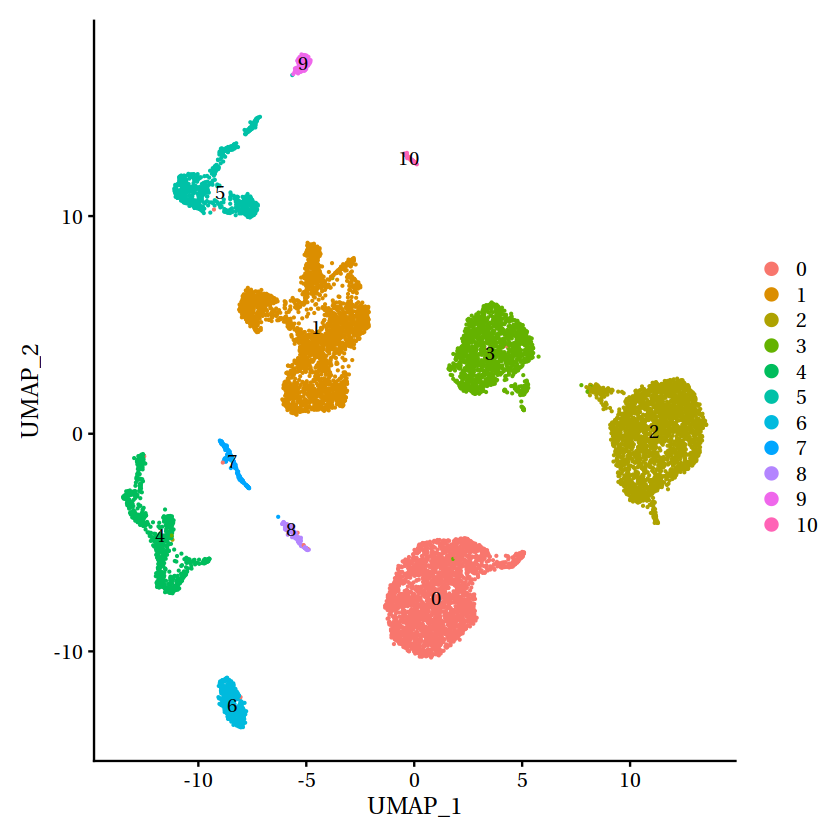

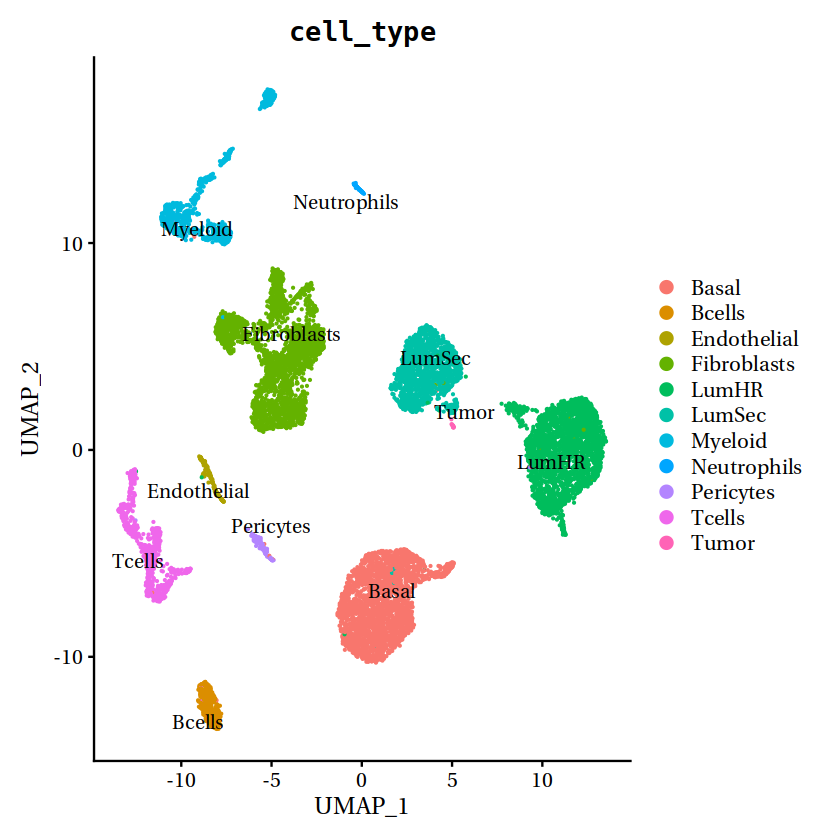

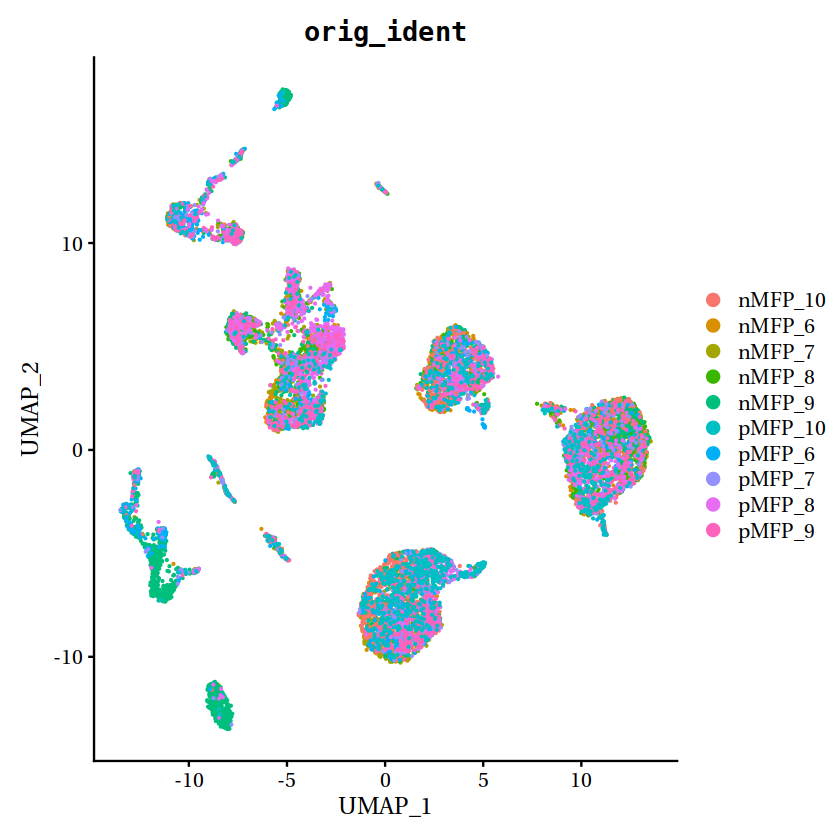

In [35]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)

In [36]:
saveRDS(obj, "cellplex3_soupX.rds")

# after doublet prediction, CNV

In [3]:
obj <- readRDS("cellplex3_soupX_doubletfinder.rds")

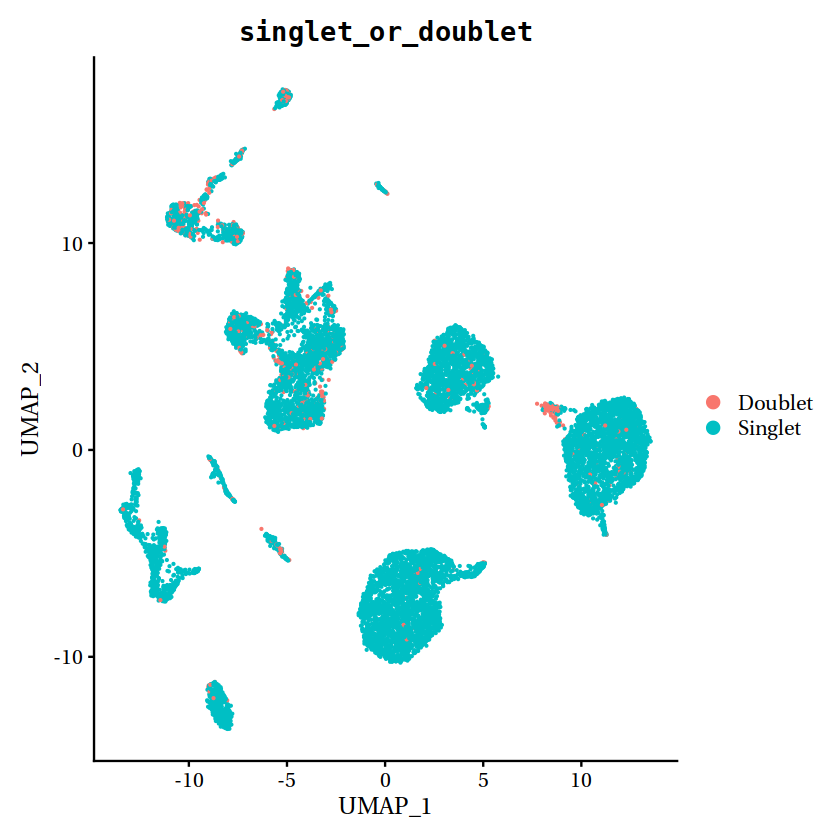

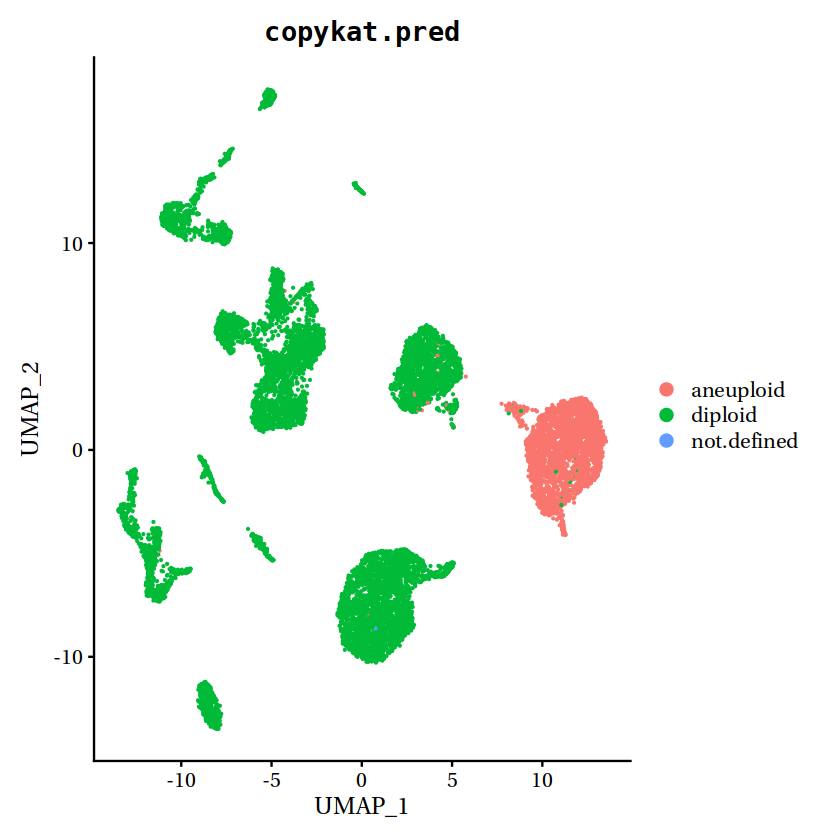

In [5]:
pred <- read.csv("cellplex_3_copykat_prediction.txt", sep = '\t')
rownames(pred) <- pred$cell.names
pred$cell.names <- NULL
obj <- AddMetaData(obj,pred)

DimPlot(obj, group.by="singlet_or_doublet")
DimPlot(obj, group.by="copykat.pred")

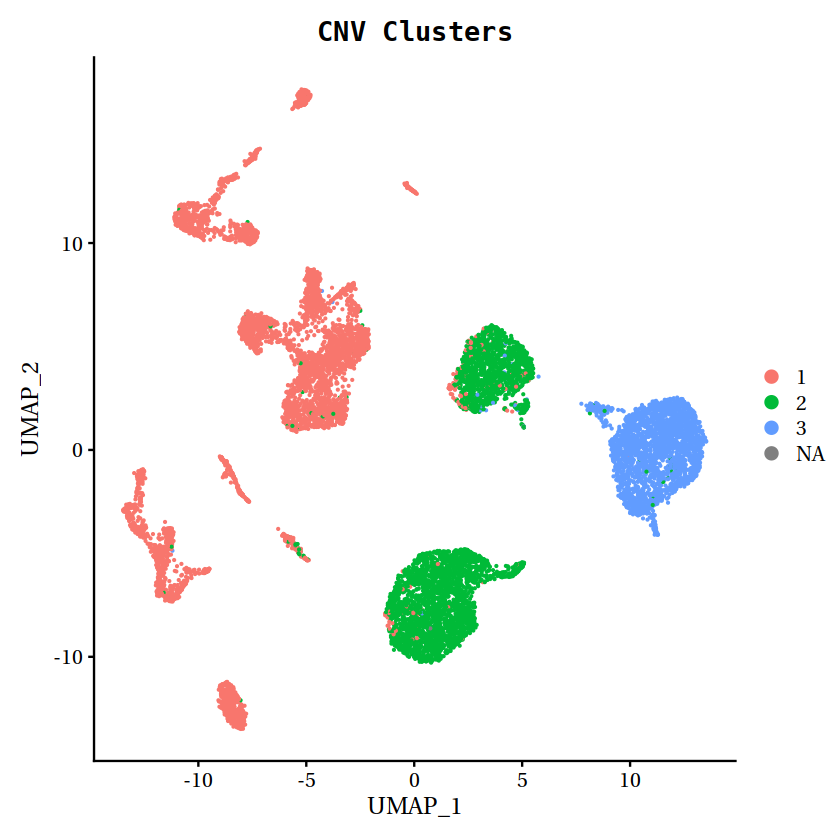

In [12]:
clust_res <- readRDS("cellplex_3_copykat_clustering_results.rds")

x <- cutree(clust_res, k = 3, h = NULL) #after seweing the heatmap
obj <- AddMetaData(obj, x, "hcluster")

DimPlot(obj, group.by = "hcluster", label =F) + ggtitle("CNV Clusters")

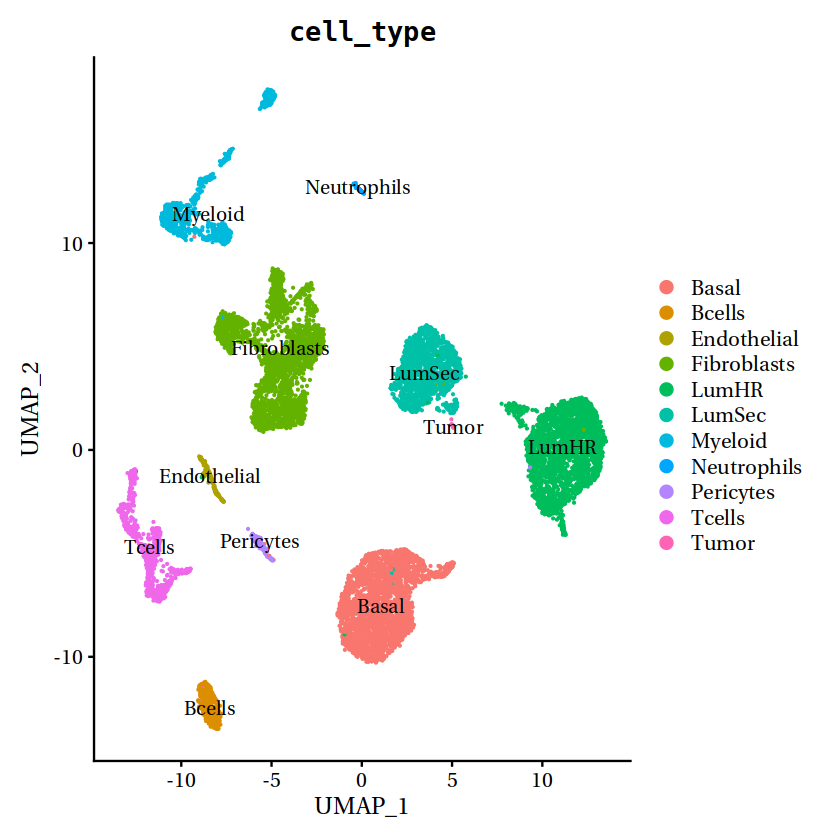

In [9]:
DimPlot(obj, group.by="cell_type", label = T)

#### normal clean up

In [1]:
sub <- subset(obj, subset = orig_ident %in% c("nMFP_11","nMFP_12","nMFP_13","nMFP_14","nMFP_15"))

ERROR: Error in subset(obj, subset = orig_ident %in% c("nMFP_11", "nMFP_12", : object 'obj' not found


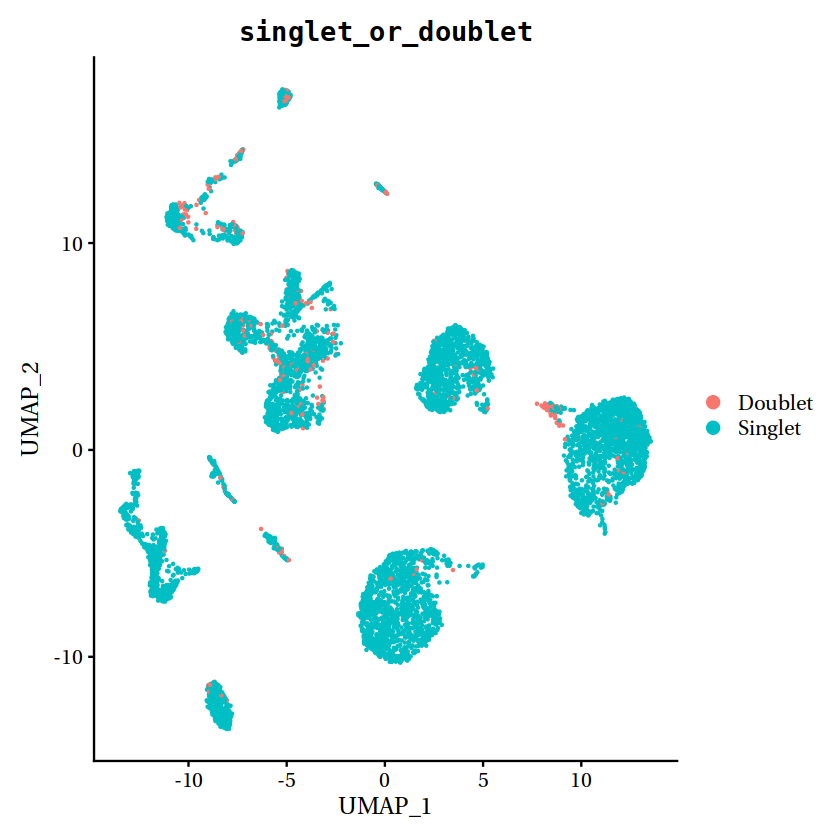

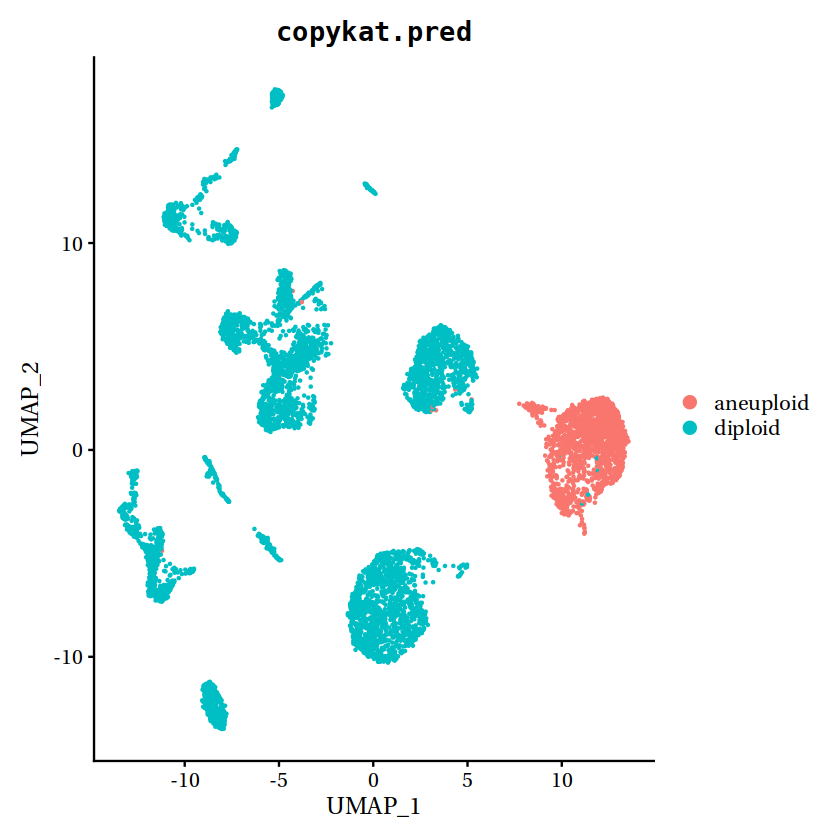

In [20]:
DimPlot(sub, group.by = "singlet_or_doublet")
DimPlot(sub, group.by="copykat.pred")

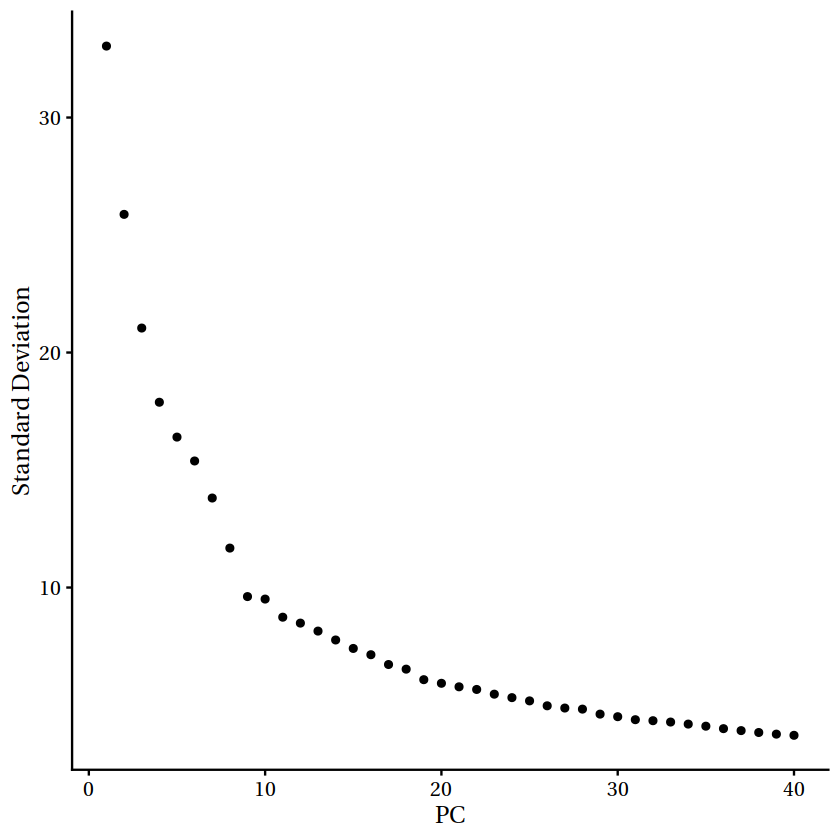

In [21]:
sub <- SCTransform(sub, variable.features.n = 1500, verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

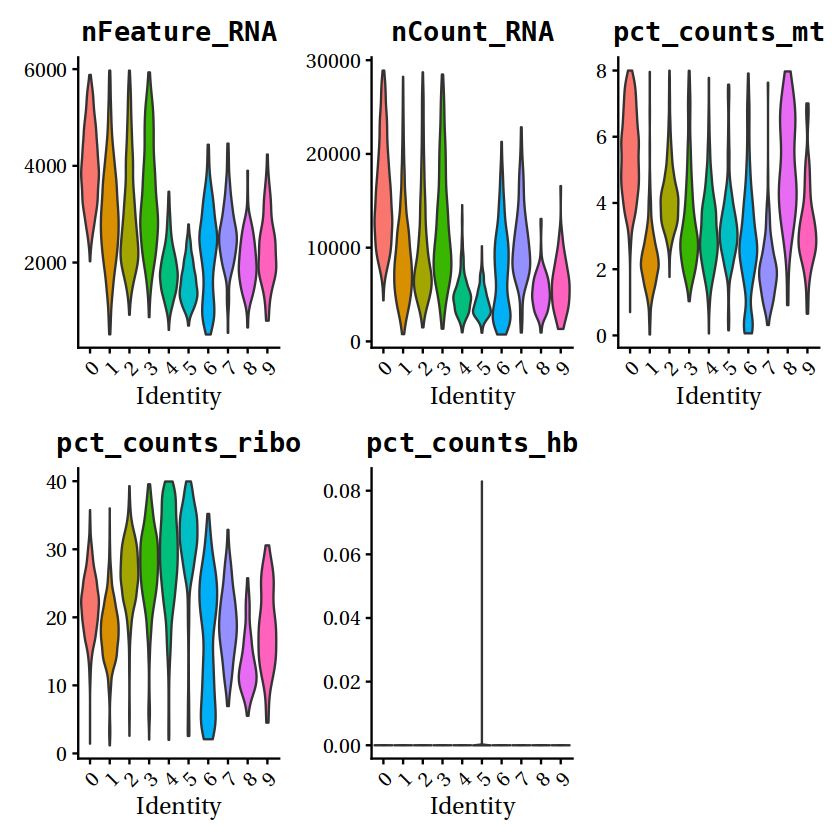

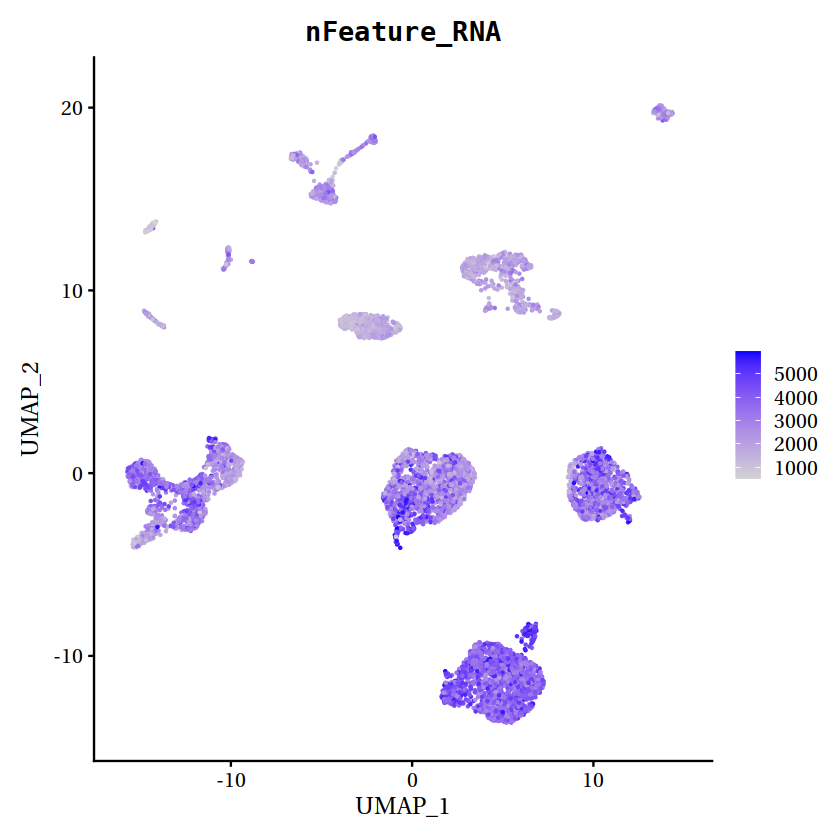

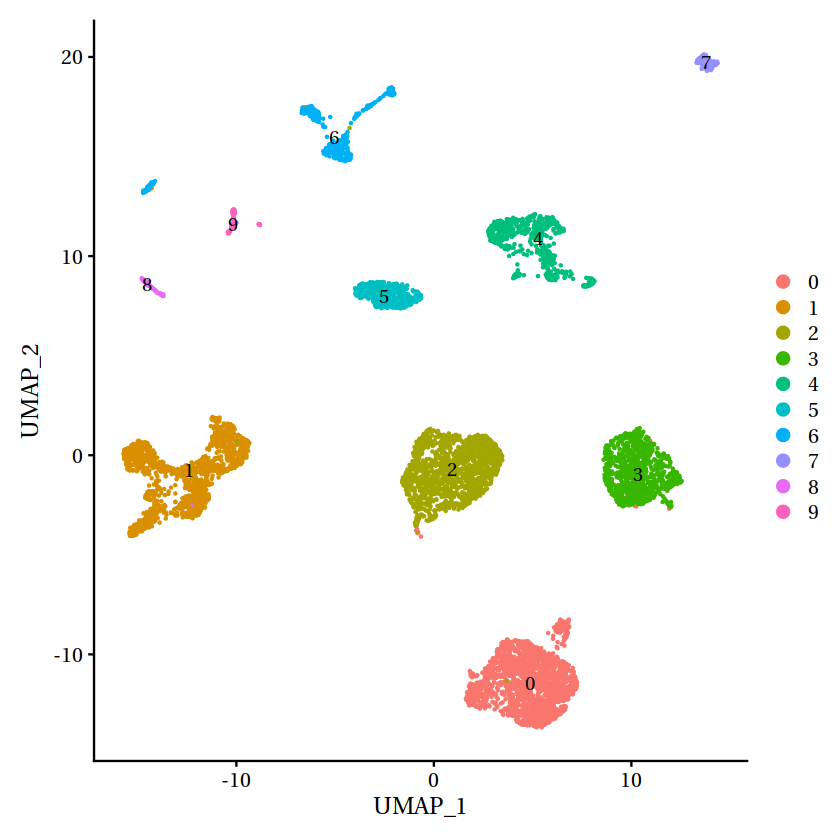

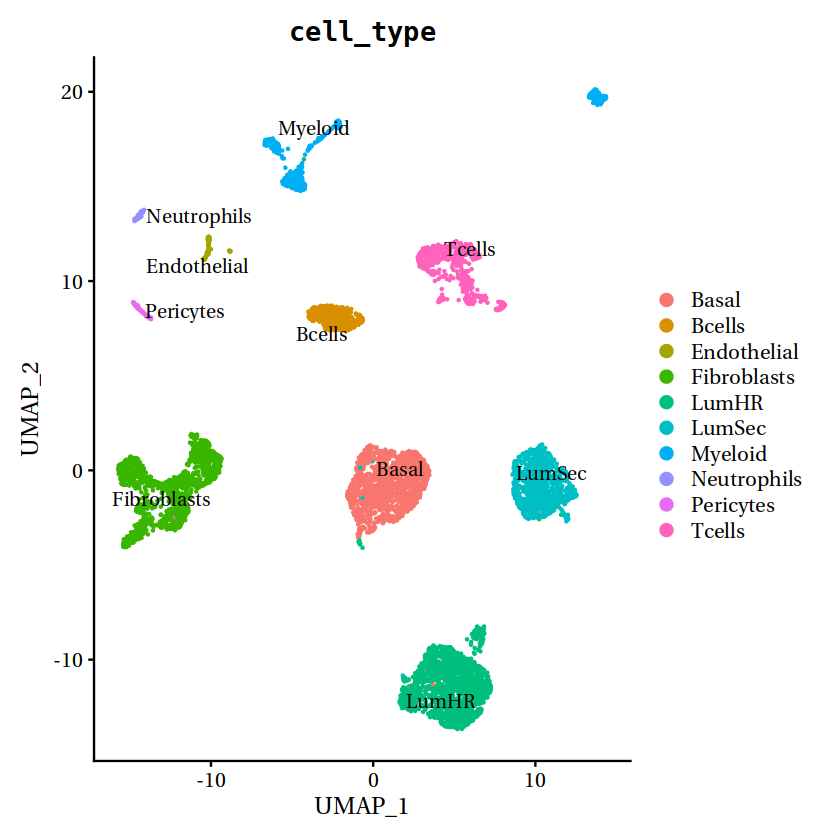

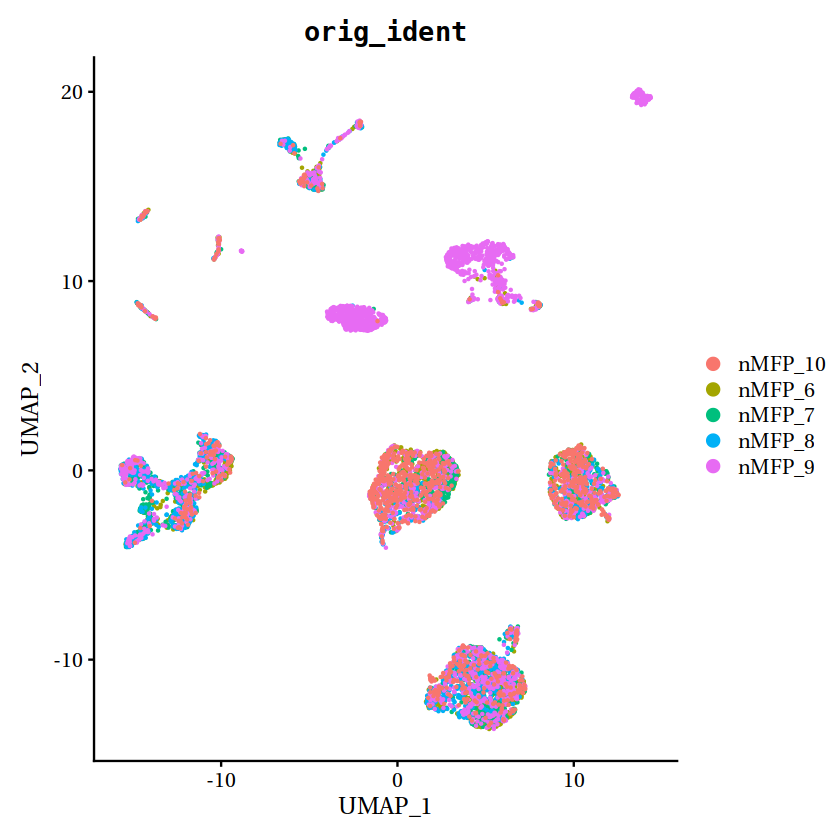

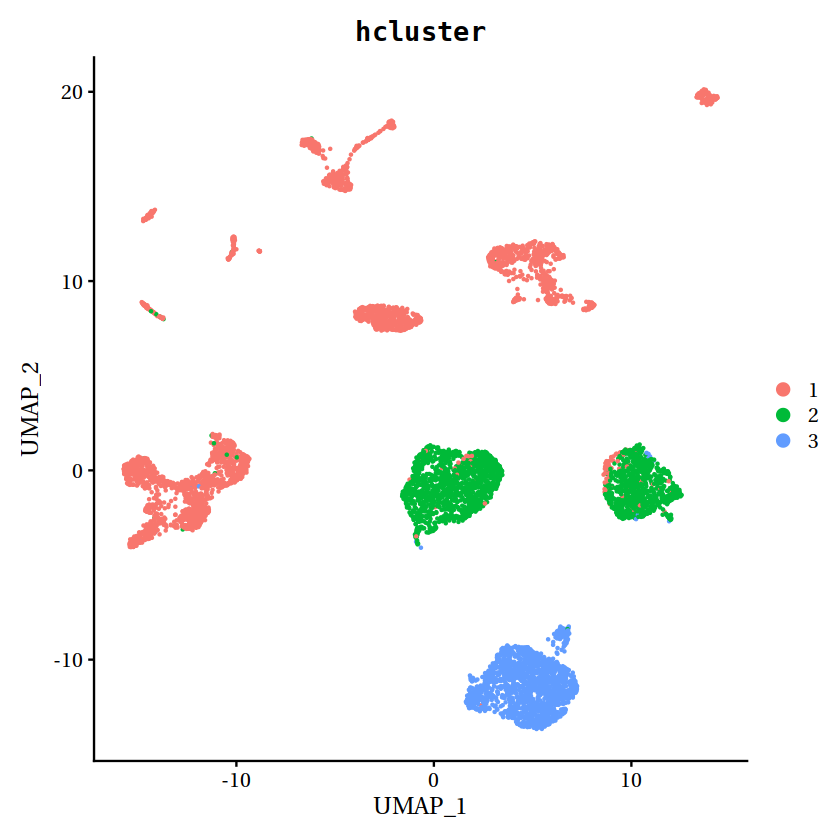

In [22]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "hcluster", label = F)

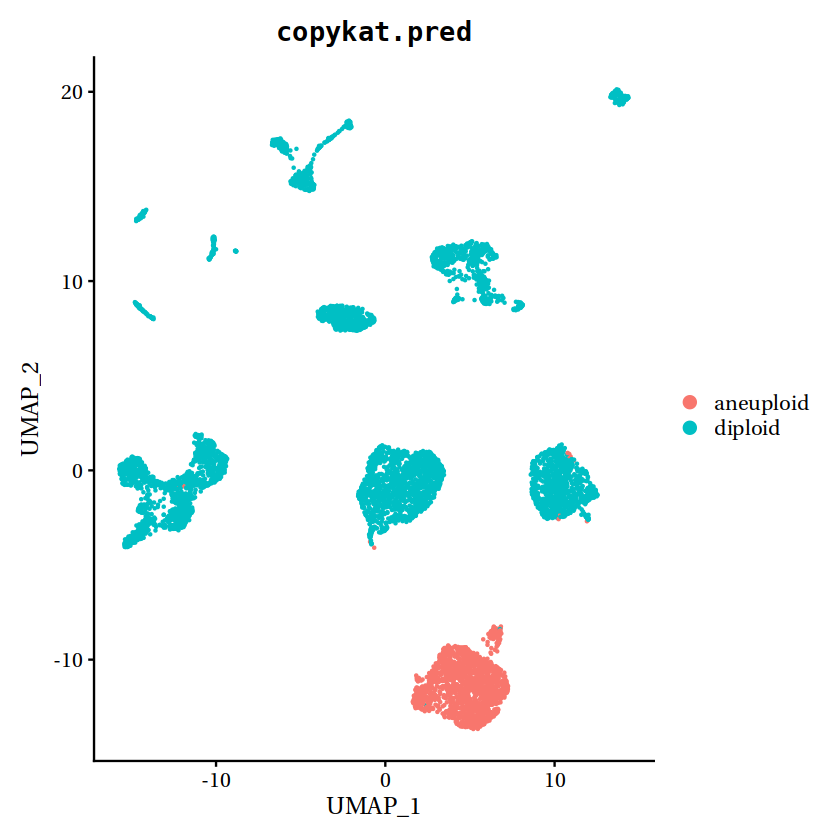

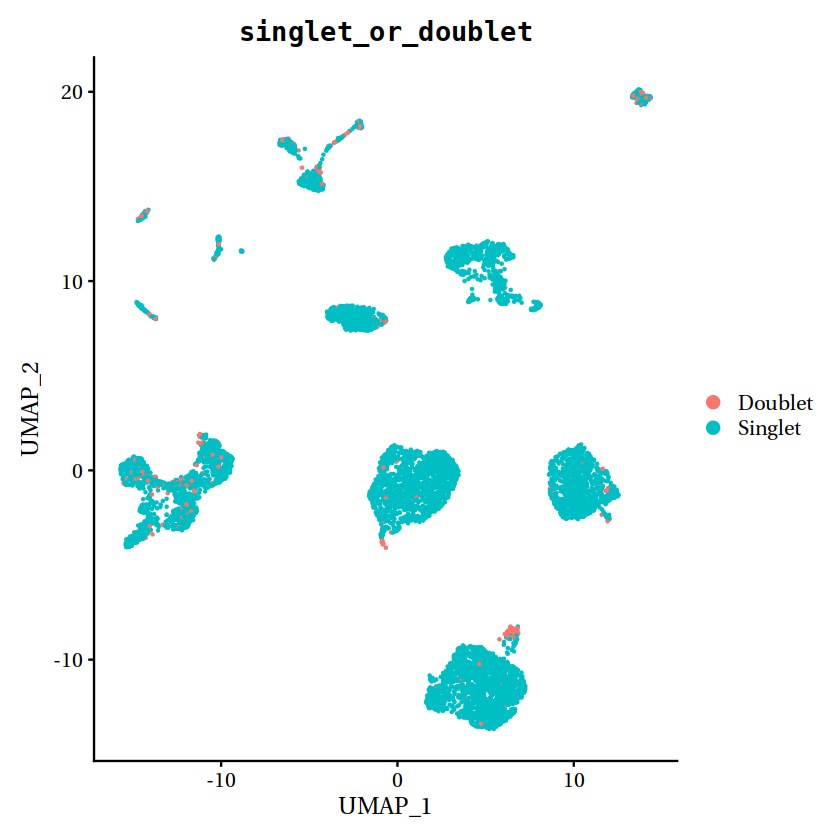

In [23]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="singlet_or_doublet")

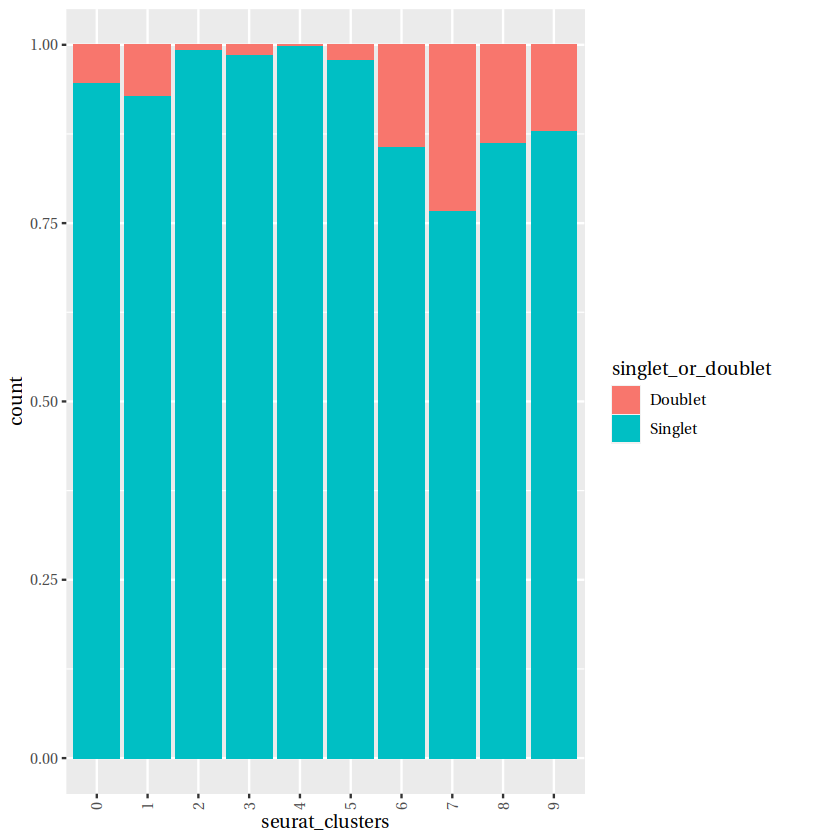

In [24]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

In [ ]:
Idents(sub) <- "cell_type"
DimPlot(sub, cells.highlight = WhichCells(sub, ident = c("Tumor")))+ggtitle("Tumor") #none

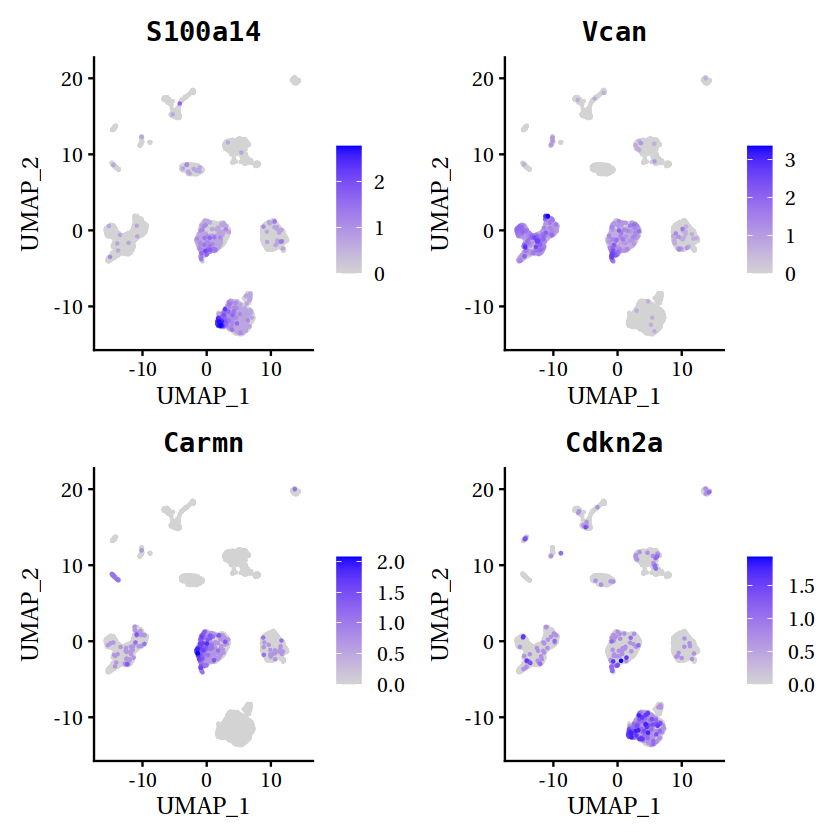

In [26]:
FeaturePlot(sub, c("S100a14","Vcan","Carmn","Cdkn2a"),order=T)

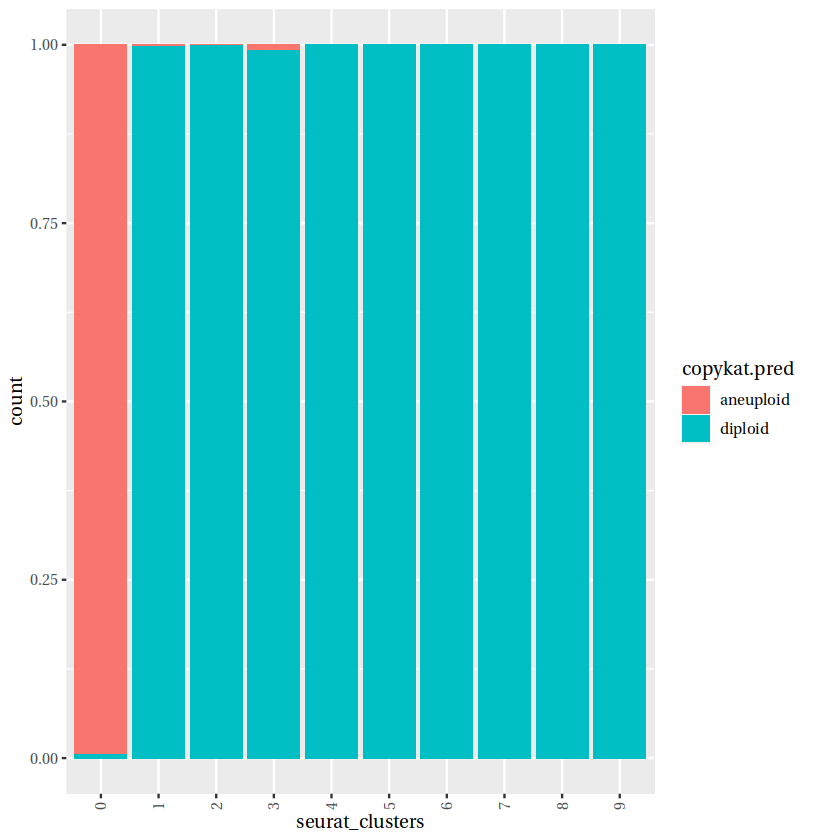

In [27]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

### check but don't save tumor 633

In [28]:
sub <- subset(obj, subset = orig_ident %in% c("nMFP_6","nMFP_7","nMFP_8","nMFP_9","nMFP_10"), invert = T)

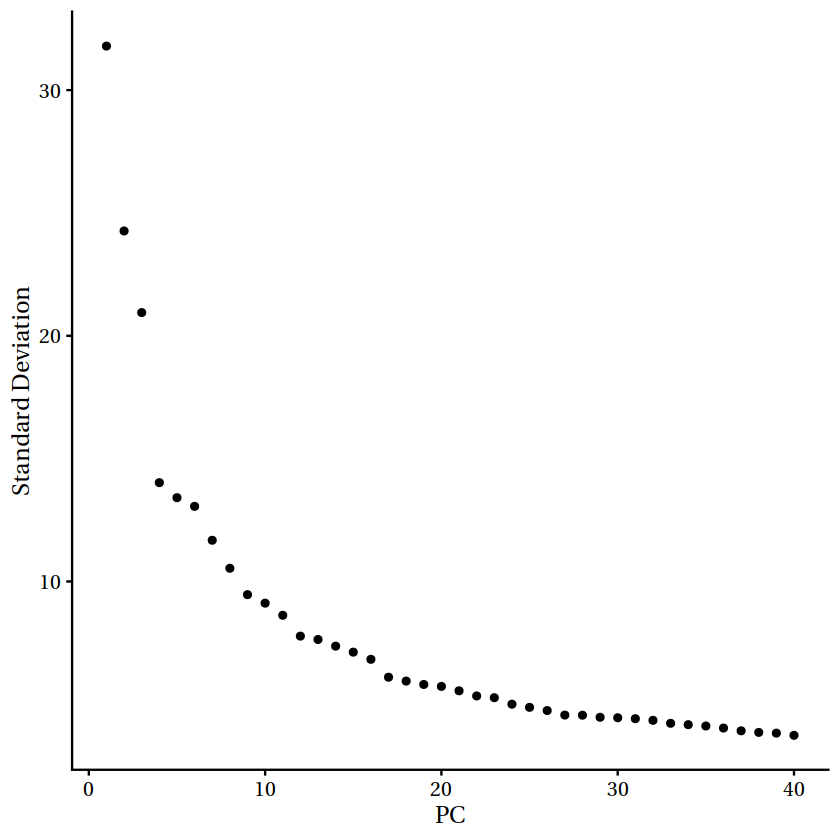

In [29]:
sub <- SCTransform(sub, variable.features.n = 1500, verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_counts_hb.”


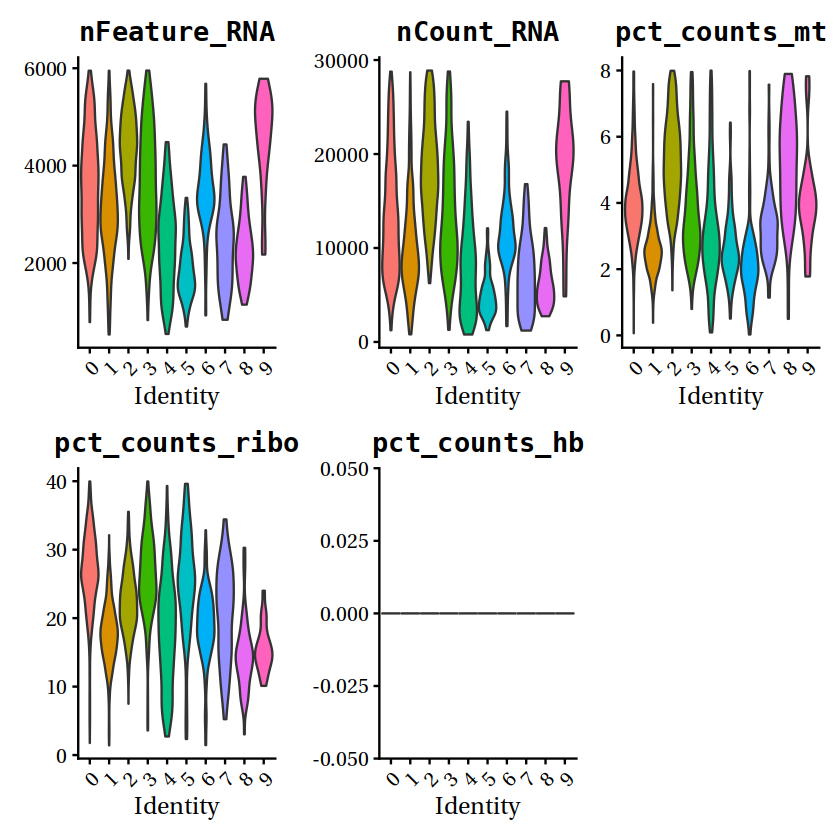

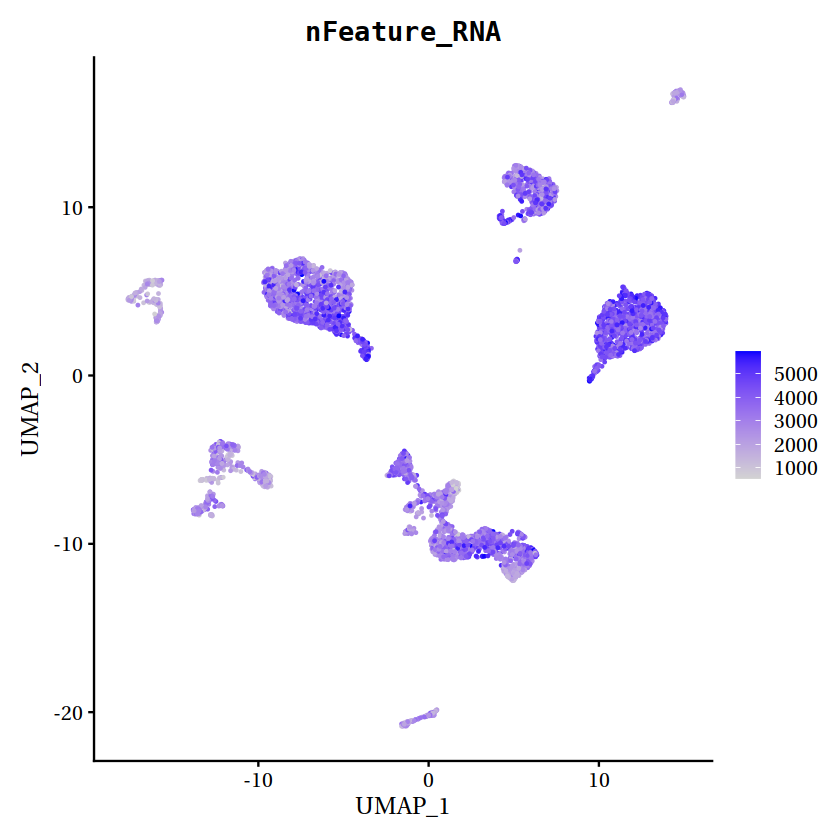

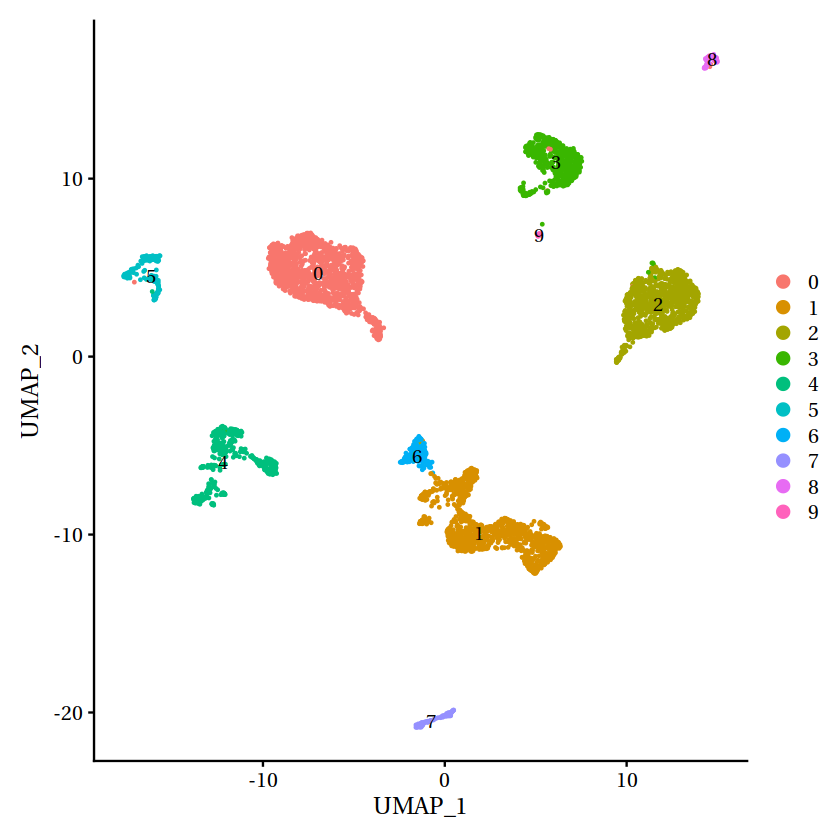

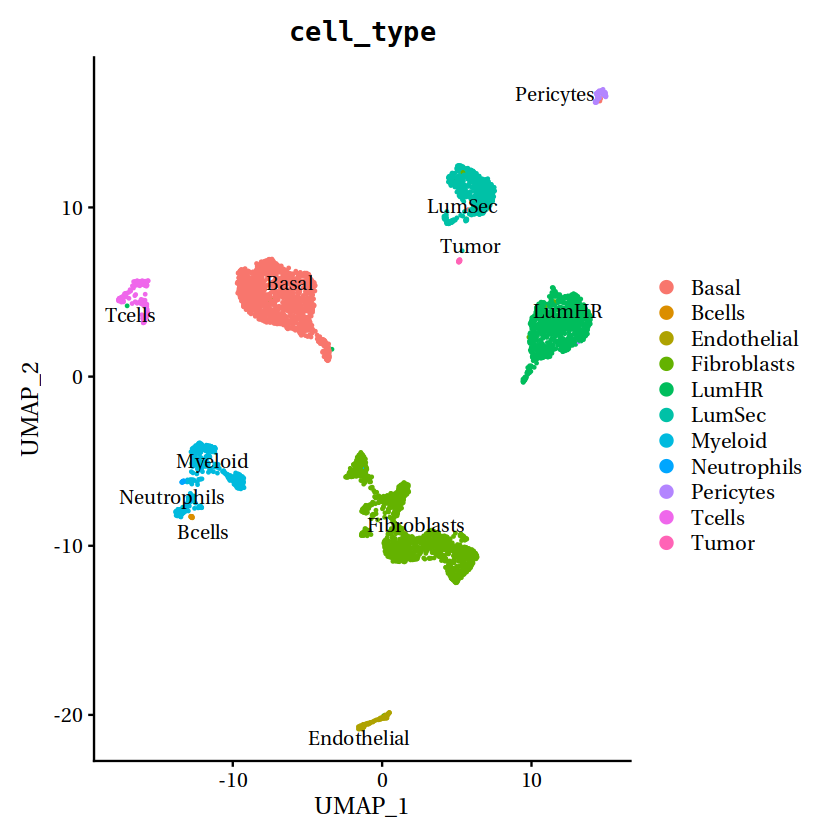

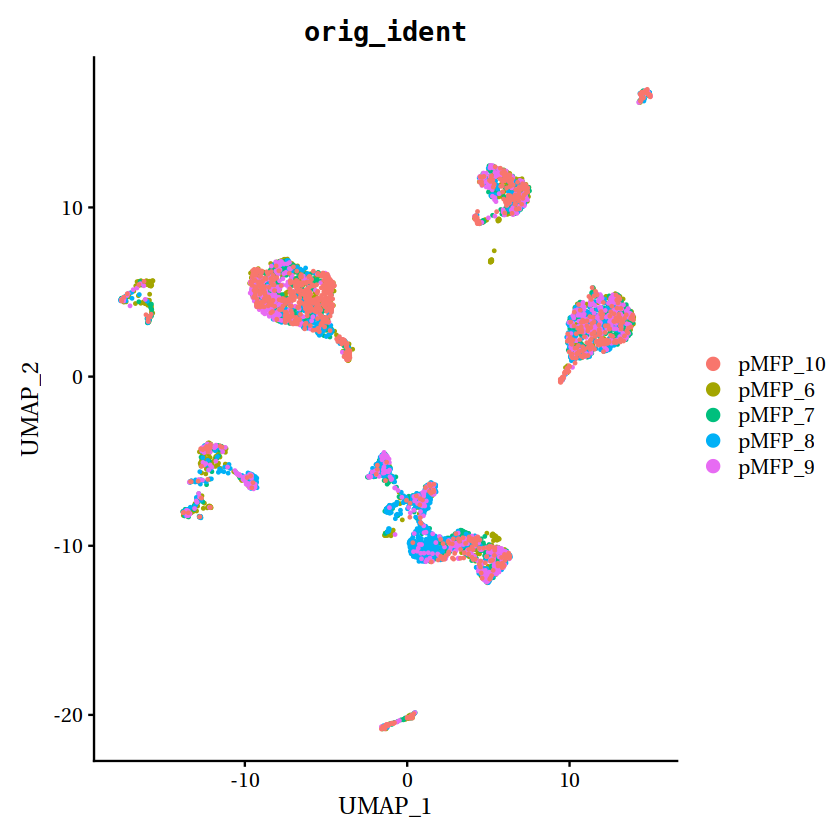

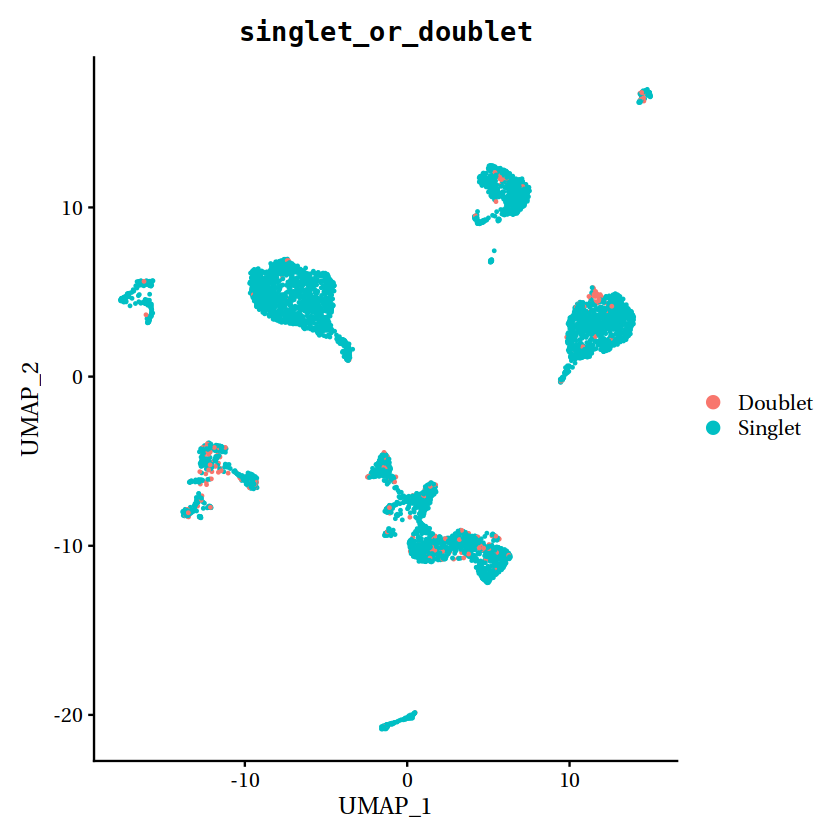

In [30]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "singlet_or_doublet", label = F)

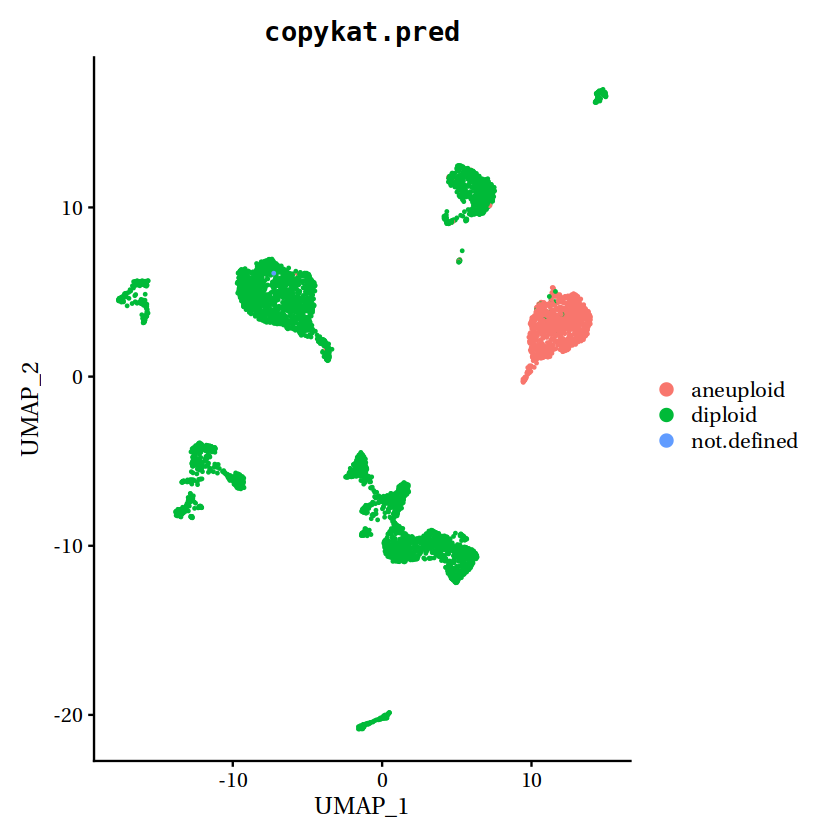

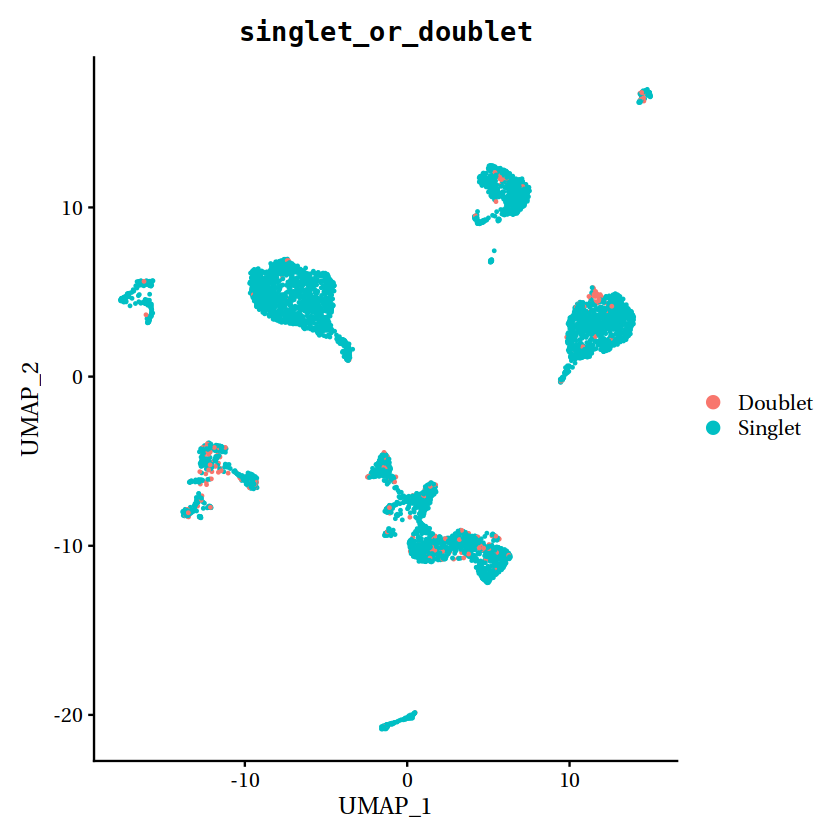

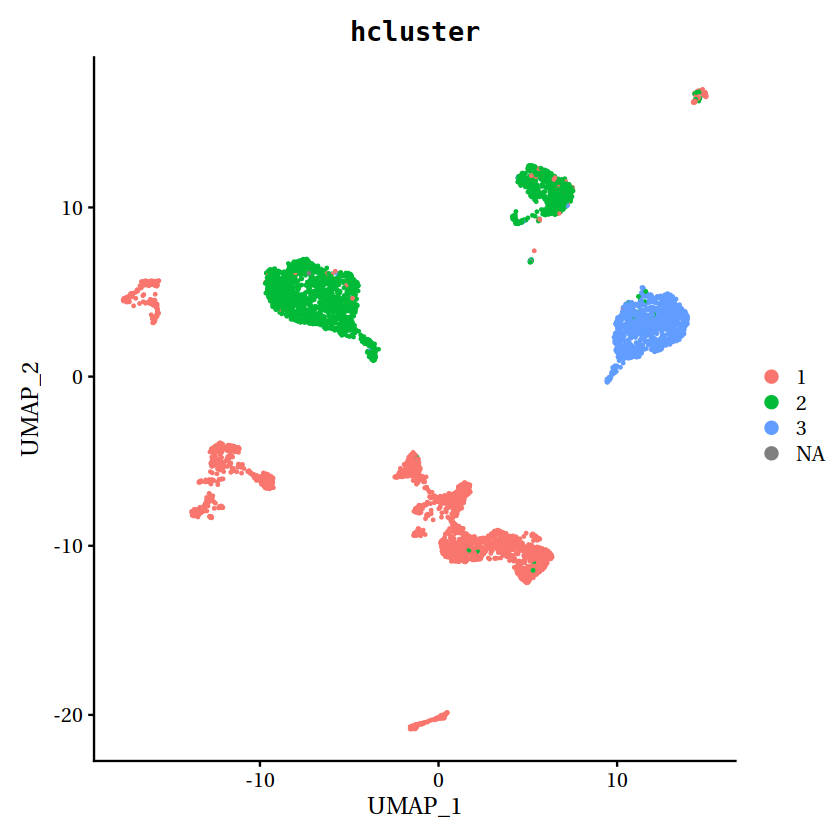

In [31]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="singlet_or_doublet")
DimPlot(sub, group.by="hcluster")

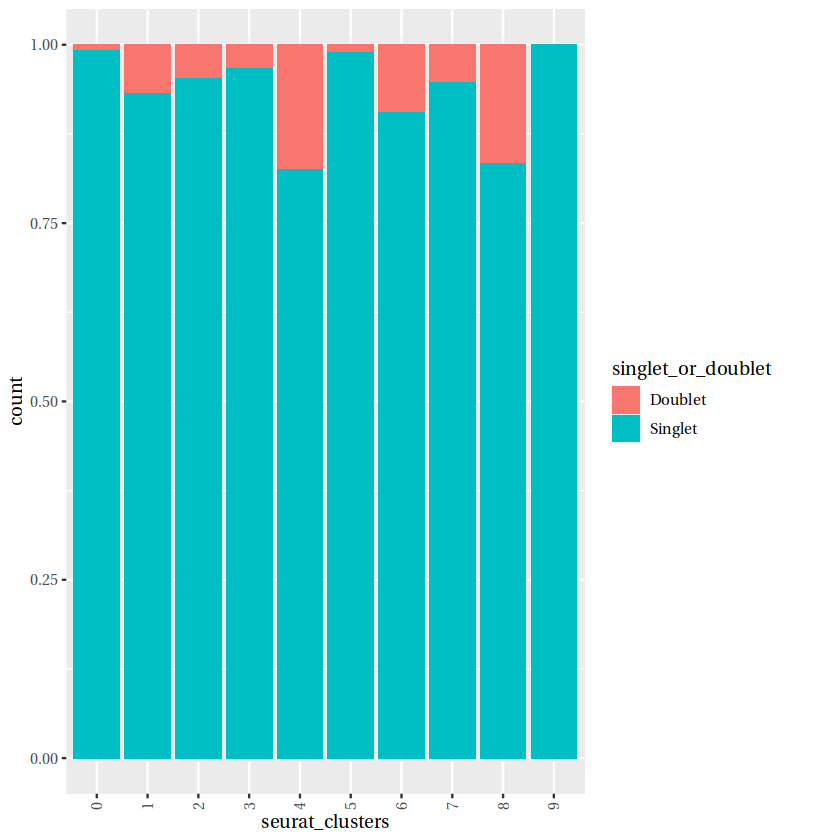

In [32]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

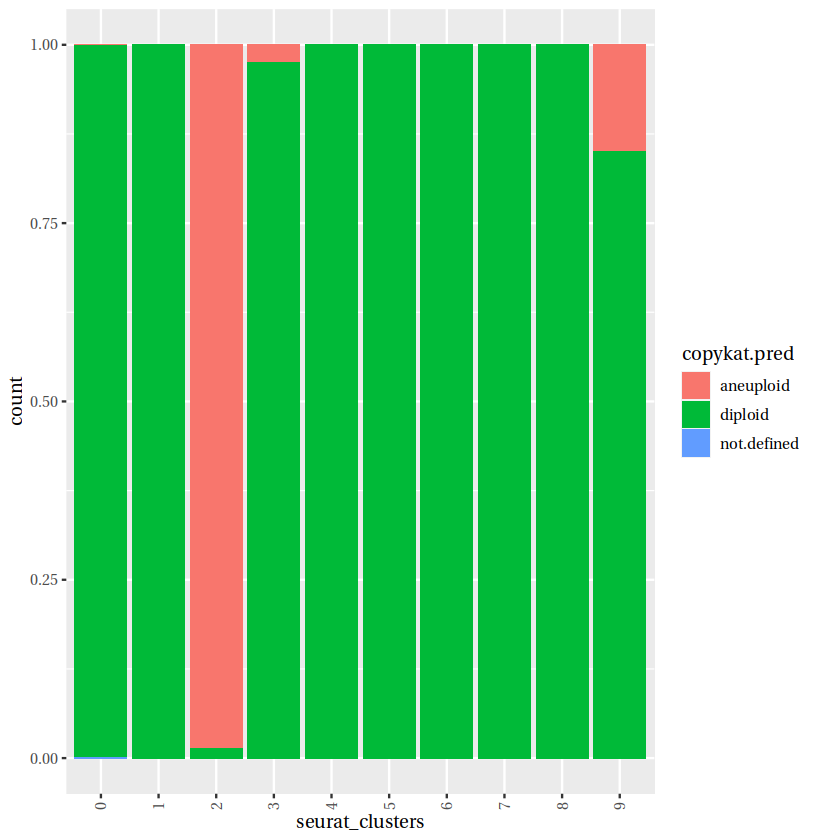

In [33]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

## clean up (remove tails)

In [34]:
Idents(obj) <- "seurat_clusters"

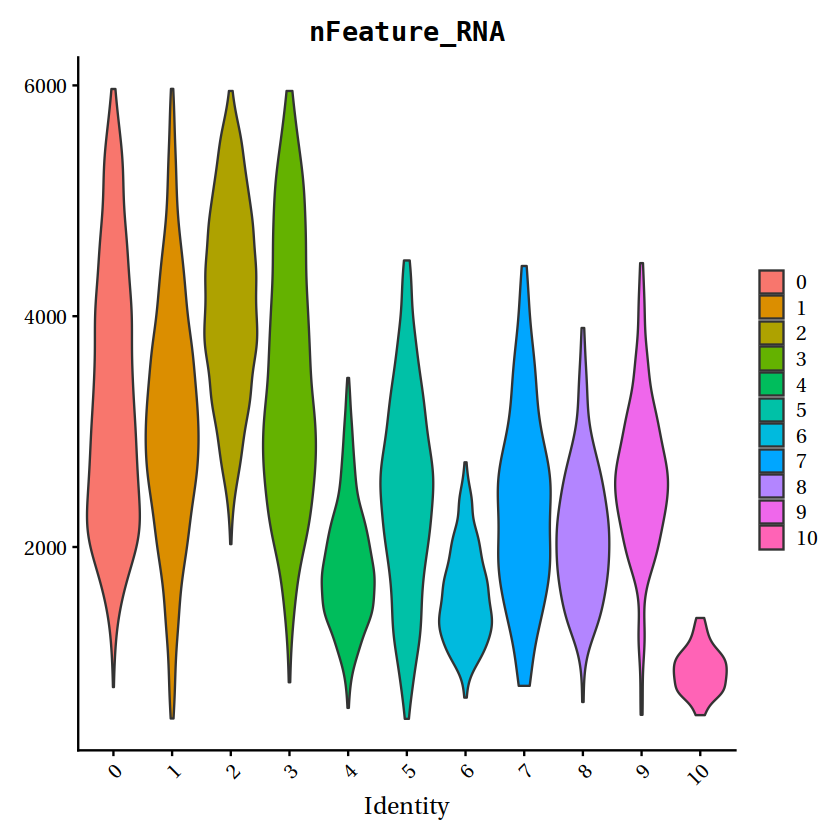

In [35]:
VlnPlot(obj, "nFeature_RNA", pt.size = 0)

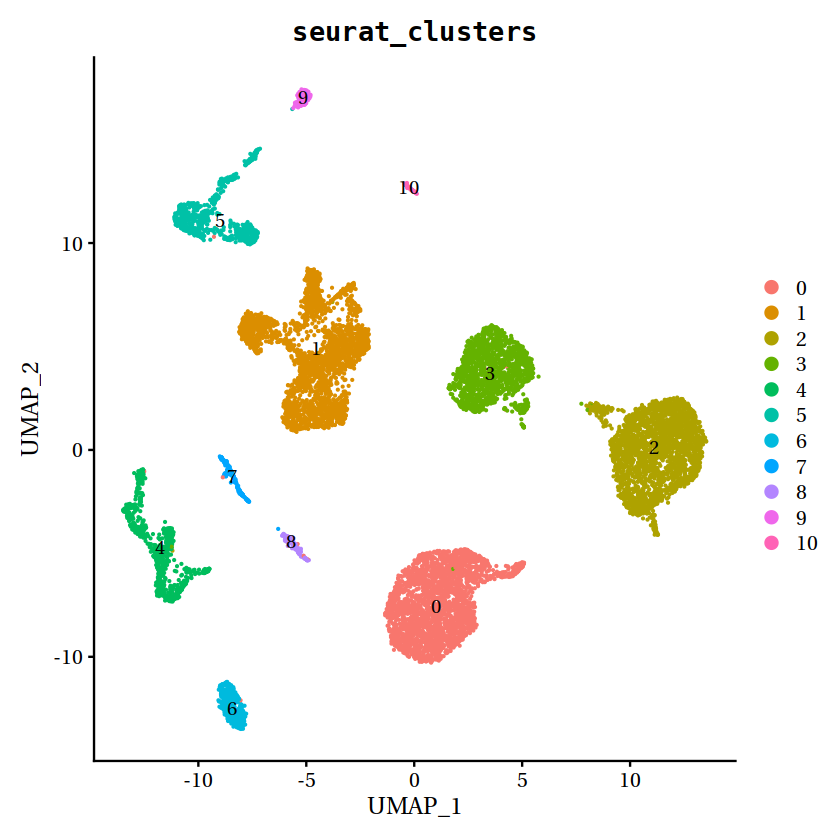

In [36]:
DimPlot(obj, group.by = "seurat_clusters", label = T)

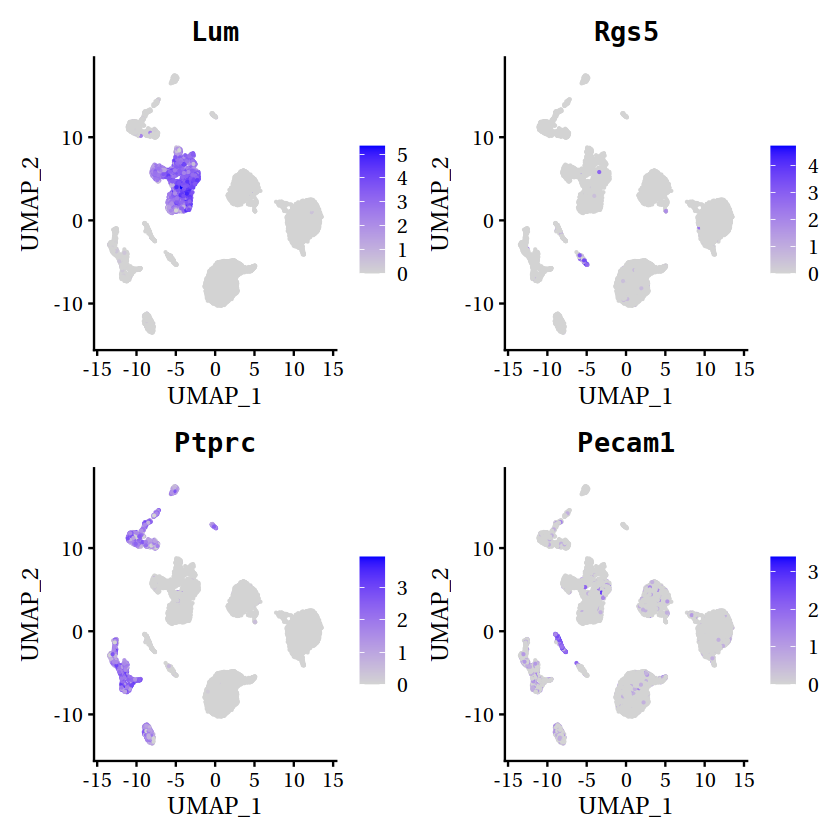

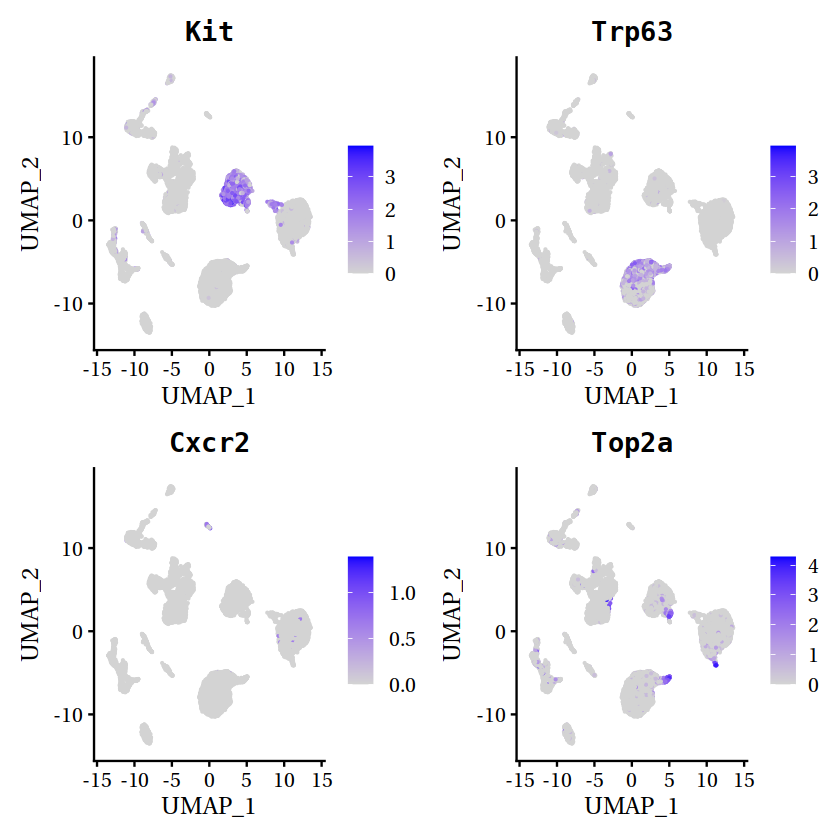

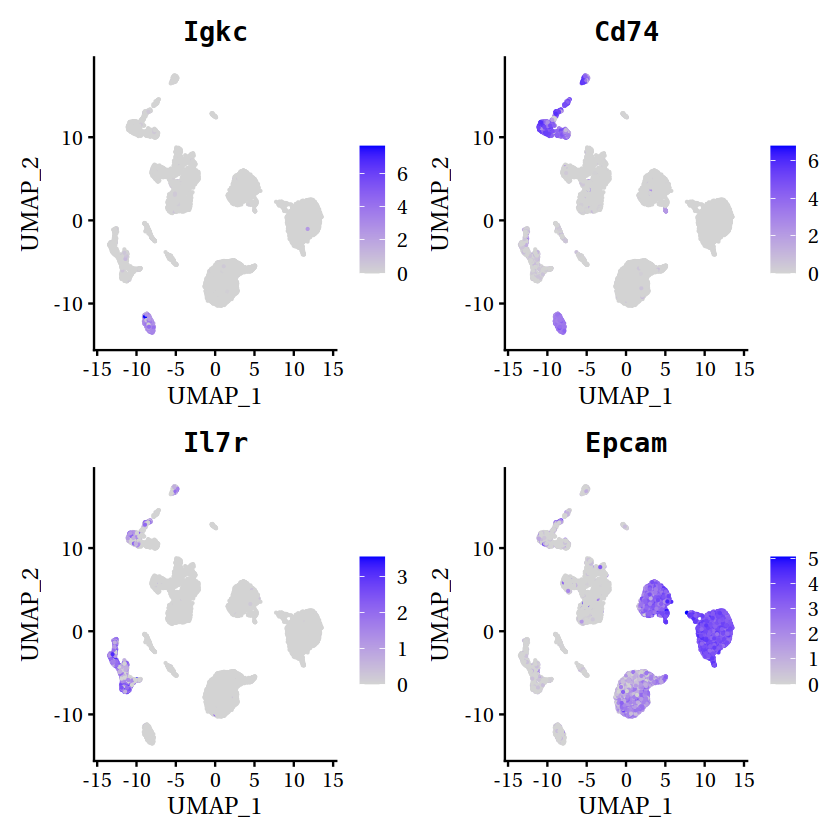

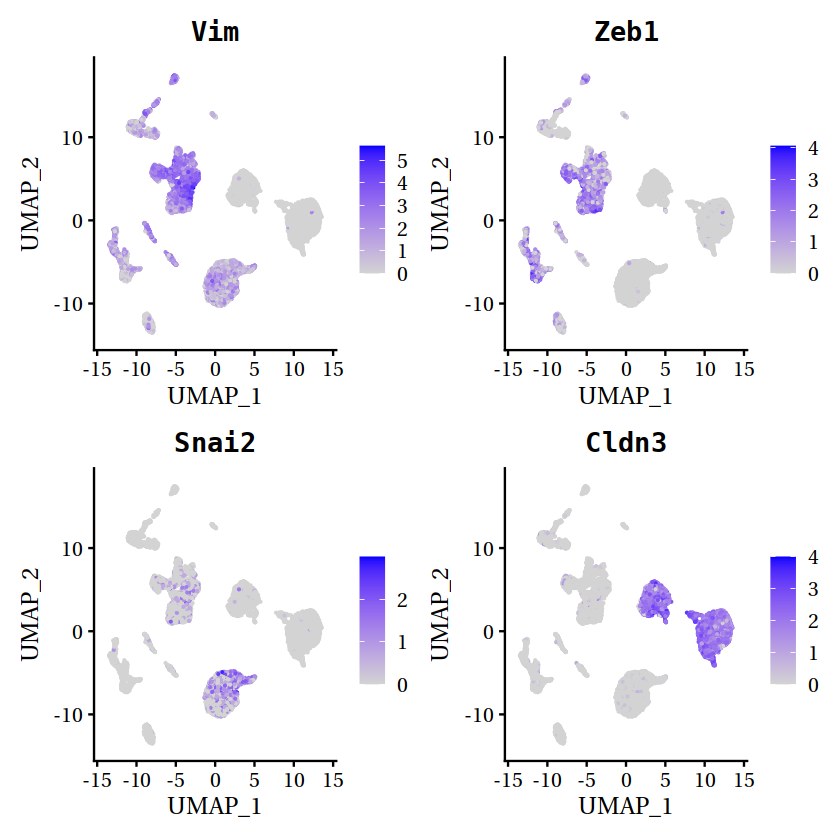

In [37]:
FeaturePlot(obj, c("Lum","Rgs5","Ptprc","Pecam1"))
FeaturePlot(obj, c("Kit","Trp63","Cxcr2","Top2a"))
FeaturePlot(obj, c("Igkc","Cd74","Il7r","Epcam"))
FeaturePlot(obj, c("Vim","Zeb1","Snai2","Cldn3"))

### add important metadata

Warning message:
“The following features are not present in the object: MCM5, PCNA, TYMS, FEN1, MCM2, MCM4, RRM1, UNG, GINS2, MCM6, CDCA7, DTL, PRIM1, UHRF1, MLF1IP, HELLS, RFC2, RPA2, NASP, RAD51AP1, GMNN, WDR76, SLBP, CCNE2, UBR7, POLD3, MSH2, ATAD2, RAD51, RRM2, CDC45, CDC6, EXO1, TIPIN, DSCC1, BLM, CASP8AP2, USP1, CLSPN, POLA1, CHAF1B, BRIP1, E2F8, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: HMGB2, CDK1, NUSAP1, UBE2C, BIRC5, TPX2, TOP2A, NDC80, CKS2, NUF2, CKS1B, MKI67, TMPO, CENPF, TACC3, FAM64A, SMC4, CCNB2, CKAP2L, CKAP2, AURKB, BUB1, KIF11, ANP32E, TUBB4B, GTSE1, KIF20B, HJURP, CDCA3, HN1, CDC20, TTK, CDC25C, KIF2C, RANGAP1, NCAPD2, DLGAP5, CDCA2, CDCA8, ECT2, KIF23, HMMR, AURKA, PSRC1, ANLN, LBR, CKAP5, CENPE, CTCF, NEK2, G2E3, GAS2L3, CBX5, CENPA, not searching for symbol synonyms”
Warning message in AddModuleScore(object = object, features = features, name = name, :
“Could not find enough features in the object 

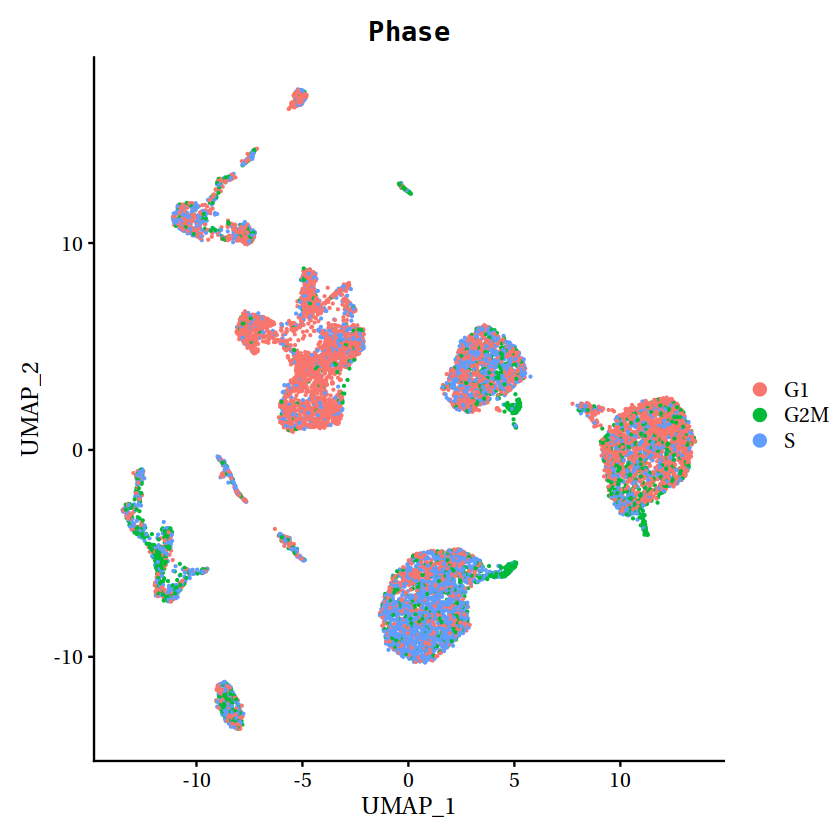

In [38]:
obj <- CellCycleScoring(obj, s.features = cc.genes$s.genes, 
                        g2m.features = cc.genes$g2m.genes, set.ident = FALSE)
DimPlot(obj, group.by = "Phase", shuffle = T)

In [39]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Basal", 
                            `1` = "Fibroblasts", 
                            `2` = "LumHR", 
                            `3` = "LumSec",
                            `4` = "Tcells",
                            `5` = "Myeloid",
                            `6` = "Bcells", 
                            `7` = "Endothelial", 
                            `8` = "Pericytes", 
                            `9` = "Myeloid",
                            `10` = "Neutrophils")
obj$cell_type <- obj@active.ident

In [41]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Epithelial", 
                            `1` = "Stromal", 
                            `2` = "Epithelial", 
                            `3` = "Epithelial",
                            `4` = "Epithelial",
                            `5` = "Immune",
                            `6` = "Immune", 
                            `7` = "Stromal", 
                            `8` = "Stromal", 
                            `9` = "Immune",
                            `10` = "Immune")
obj$cell_type_group <- obj@active.ident

In [43]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_6` = "wildtype", 
                            `nMFP_7` = "wildtype", 
                            `nMFP_8` = "wildtype",
                            `nMFP_9` = "wildtype",
                            `nMFP_10` = "wildtype",
                            `pMFP_6` = "mutant", 
                            `pMFP_7` = "mutant", 
                            `pMFP_8` = "mutant",
                            `pMFP_9` = "mutant",
                            `pMFP_10` = "mutant")
obj$genotype <- obj@active.ident

In [44]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_6` = "normal", 
                            `nMFP_7` = "normal", 
                            `nMFP_8` = "normal",
                            `nMFP_9` = "normal",
                            `nMFP_10` = "normal",
                            `pMFP_6` = "mutant", 
                            `pMFP_7` = "mutant", 
                            `pMFP_8` = "mutant",
                            `pMFP_9` = "mutant",
                            `pMFP_10` = "mutant")
obj$condition_metastatic_burden <- obj@active.ident

In [45]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_6` = "normal", 
                            `nMFP_7` = "normal", 
                            `nMFP_8` = "normal",
                            `nMFP_9` = "normal",
                            `nMFP_10` = "normal",
                            `pMFP_6` = "mutant", 
                            `pMFP_7` = "mutant", 
                            `pMFP_8` = "mutant",
                            `pMFP_9` = "mutant",
                            `pMFP_10` = "mutant")
obj$condition_tumor_size_mm <- obj@active.ident

In [46]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_6` = "normal", 
                            `nMFP_7` = "normal", 
                            `nMFP_8` = "normal",
                            `nMFP_9` = "normal",
                            `nMFP_10` = "normal",
                            `pMFP_6` = "mutant", 
                            `pMFP_7` = "mutant", 
                            `pMFP_8` = "mutant",
                            `pMFP_9` = "mutant",
                            `pMFP_10` = "mutant")
obj$condition <- obj@active.ident

In [47]:
obj$cellplex <- "3"
obj$organ <- "mammary"
obj$transplant_status <- "original"
obj$sc_assay <- "cellplex_GEX_v3.1"

In [48]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_6` = "removed", 
                            `nMFP_7` = "removed", 
                            `nMFP_8` = "removed",
                            `nMFP_9` = "intact",
                            `nMFP_10` = "removed",
                            `pMFP_6` = "removed", 
                            `pMFP_7` = "removed", 
                            `pMFP_8` = "removed",
                            `pMFP_9` = "removed",
                            `pMFP_10` = "removed")
obj$lymph_node_presence <- obj@active.ident

In [49]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `nMFP_6` = "wildtype_2", 
                            `nMFP_7` = "wildtype_2", 
                            `nMFP_8` = "wildtype_2",
                            `nMFP_9` = "wildtype_2",
                            `nMFP_10` = "wildtype_2",
                            `pMFP_6` = "mutant_2", 
                            `pMFP_7` = "mutant_2", 
                            `pMFP_8` = "mutant_2",
                            `pMFP_9` = "mutant_2",
                            `pMFP_10` = "mutant_2")
obj$mouse <- obj@active.ident

In [50]:
as.data.frame(colnames(obj[[]]))

colnames(obj[[]])
<chr>
orig.ident
nCount_RNA
nFeature_RNA
orig_ident
pct_counts_mt
pct_counts_ribo
pct_counts_hb
leiden_res_0.10
cell_type


In [51]:
obj$S.Score <- NULL
obj$G2M.Score <- NULL
obj$SCT_snn_res.0.1 <- NULL

In [52]:
meta <- read.csv("cellplex3.adata.obs.metadata.csv", row.names=1)
obj <- AddMetaData(obj, meta['cell_type'], "orig_cell_type")

In [53]:
saveRDS(obj, "cellplex3_soupX_doubletfinder_cnv_metadata.rds")

In [ ]:
## dooubletfinder was redine after this, on the fnal object